# Práctico 3 — Aprendizaje Supervisado y No Supervisado
## DiploDatos 2026 · Ciencia de Datos Aplicada al Fútbol

**Objetivos de aprendizaje**
- Implementar el framework VAEP (Valuing Actions by Estimating Probabilities) completo
- Implementar y comparar el framework xT (Expected Threat)
- Usar XGBoost y LightGBM para predicción de valor de acciones
- Interpretar modelos con SHAP (SHapley Additive exPlanations)
- Aplicar clustering (K-Means + UMAP) para identificar perfiles de jugadores
- Construir un sistema de scouting basado en similitud

**Referencias clave**:
- Decroos et al. (2019) *Actions Speak Louder than Goals: Valuing Player Actions in Football*
- Van Roy et al. (2020) *Valuing on-the-ball actions in soccer: a critical comparison of XT and VAEP*
- Singh (2019) *Introducing Expected Threat* (blog)

---

## Carga de datos y librerías

In [1]:
# Instalación de dependencias
#%pip install socceraction "xgboost==2.1.4" lightgbm shap umap-learn scikit-learn pandas numpy matplotlib mplsoccer

In [2]:
import warnings
import numpy as np
import pandas as pd
import codecs
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm

# ML
import xgboost as xgb
import lightgbm as lgb
import shap
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import umap

# socceraction
import socceraction.spadl as spadl
import socceraction.vaep.features as features
import socceraction.vaep.labels as labels
import socceraction.vaep.formula as vaep_formula

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✓ Librerías cargadas')

✓ Librerías cargadas


In [3]:
# Cargamos el dataset curado del Práctico 2
from pathlib import Path

dataset_path = Path("./spadl_curado_PL_2017.parquet")
if not dataset_path.exists():
    dataset_path = Path("../data/processed/spadl_curado_PL_2017.parquet")
if not dataset_path.exists():
    dataset_path = Path("spadl_curado_PL_2017.parquet")

df_clean = pd.read_parquet(dataset_path)
print(f"Dataset cargado: {df_clean.shape}")
print(f"Partidos únicos: {df_clean['game_id'].nunique()} | Jugadores únicos: {df_clean['player_id'].nunique()}")


Dataset cargado: (1454478, 26)
Partidos únicos: 1140 | Jugadores únicos: 1582


In [4]:
# Ajustamos codificacion de caracteres especiales
df_clean['short_name']=df_clean['short_name'].apply(lambda x: codecs.decode(x, 'unicode_escape') if isinstance(x, str) else x)
df_clean['team_name']=df_clean['team_name'].apply(lambda x: codecs.decode(x, 'unicode_escape') if isinstance(x, str) else x)

## PARTE A — Aprendizaje Supervisado


### 1. Framework xT (Expected Threat)

xT fue propuesto por Karun Singh en 2019. La idea central: el campo se divide en zonas y
a cada zona se le asigna un valor que refleja cuán amenazante es estar ahí.

**Formalmente**: xT(z) = P(shoot|z) × P(goal|shoot, z) + P(move|z) × Σ P(move to z'|move, z) × xT(z')

Es un modelo iterativo que converge en ~10 iteraciones.

In [5]:
def compute_xt_grid(df_actions: pd.DataFrame, M: int = 16, N: int = 12, 
                    n_iter: int = 10) -> tuple:
    """
    Implementación del modelo xT (Expected Threat).
    
    Parámetros
    ----------
    df_actions : DataFrame SPADL
    M, N       : dimensiones de la grilla (M columnas, N filas)
    n_iter     : iteraciones hasta convergencia
    
    Retorna
    -------
    (xT, pct_shoot, pct_goal) : arrays (M, N) con valores de amenaza por zona
    """
    # Asignamos cada acción a su celda de grilla
    df = df_actions.copy()
    df["cell_x"] = np.clip((df["start_x"] / 105 * M).astype(int), 0, M-1)
    df["cell_y"] = np.clip((df["start_y"] / 68 * N).astype(int), 0, N-1)
    df["end_cell_x"] = np.clip((df["end_x"].fillna(df["start_x"]) / 105 * M).astype(int), 0, M-1)
    df["end_cell_y"] = np.clip((df["end_y"].fillna(df["start_y"]) / 68 * N).astype(int), 0, N-1)
    
    # Máscara de tiros
    shot_names = ["shot", "shot_penalty", "penalty_shot", "shot_freekick", "freekick_shot"]
    shots = df[df["type_name"].isin(shot_names)]
    moves = df[~df["type_name"].isin(shot_names)]
    
    pct_shoot = np.zeros((M, N))
    pct_goal  = np.zeros((M, N))
    pct_move  = np.zeros((M, N))
    
    for (cx, cy), group in df.groupby(["cell_x", "cell_y"]):
        n_total = len(group)
        n_shots = len(group[group["type_name"].isin(shot_names)])
        n_goals = len(group[(group["type_name"].isin(shot_names)) & (group["result_name"] == "success")])
        pct_shoot[cx, cy] = n_shots / max(n_total, 1)
        pct_goal[cx, cy]  = n_goals / max(n_shots, 1)
        pct_move[cx, cy]  = 1 - pct_shoot[cx, cy]

    # Matriz de transición de movimientos P(z' | z) optimizada
    transition = np.zeros((M, N, M, N))
    total_from_dict = moves.groupby(["cell_x", "cell_y"]).size().to_dict()
    for (cx, cy, ecx, ecy), count in moves.groupby(
        ["cell_x", "cell_y", "end_cell_x", "end_cell_y"]
    ).size().items():
        tf = total_from_dict.get((cx, cy), 0)
        if tf > 0:
            transition[cx, cy, ecx, ecy] = count / tf

    # Iteración de valor (Value Iteration)
    xT = np.zeros((M, N))
    for iteration in range(n_iter):
        xT_prev = xT.copy()
        # Valor de mover = suma ponderada de xT de destinos
        move_value = np.einsum("xyzw,zw->xy", transition, xT_prev)
        xT = pct_shoot * pct_goal + pct_move * move_value
        delta = np.max(np.abs(xT - xT_prev))
        if (iteration + 1) % 2 == 0:
            print(f"  Iteración {iteration+1}: Δmax = {delta:.6f}")

    return xT, pct_shoot, pct_goal

print("Computando grilla xT (M=16, N=12)...")
xT_grid, pshot_grid, pgoal_grid = compute_xt_grid(df_clean, M=16, N=12, n_iter=10)


Computando grilla xT (M=16, N=12)...
  Iteración 2: Δmax = 0.056220
  Iteración 4: Δmax = 0.021322
  Iteración 6: Δmax = 0.011740
  Iteración 8: Δmax = 0.008849
  Iteración 10: Δmax = 0.007750


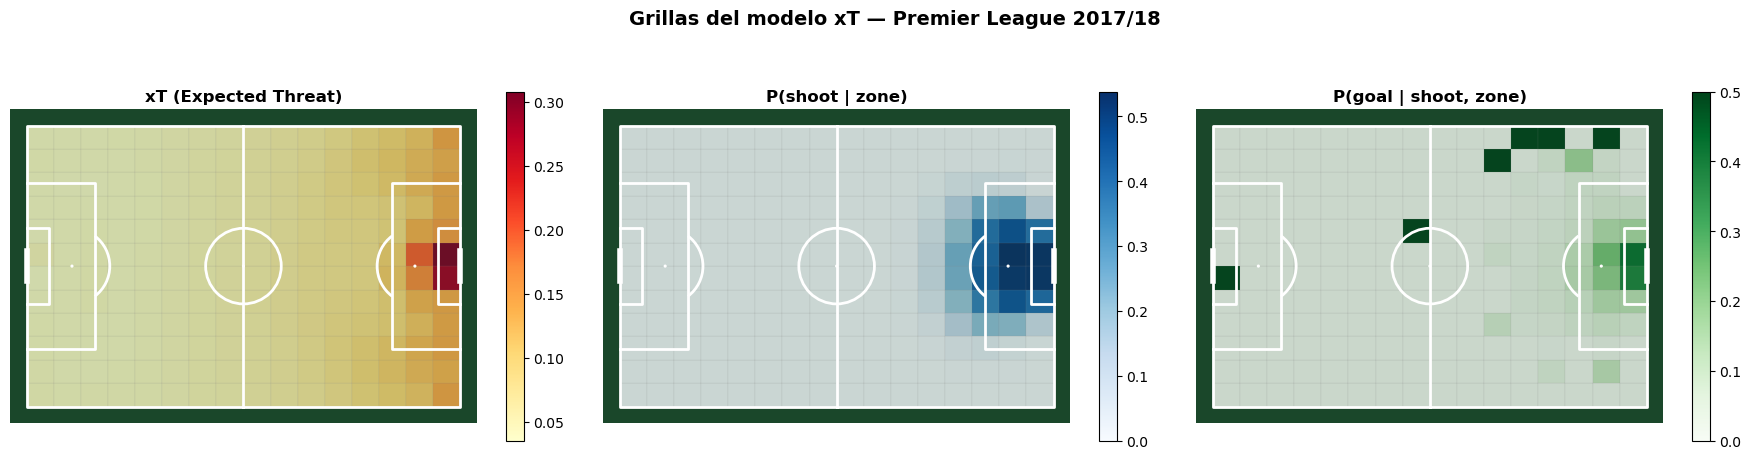

In [6]:
# Visualización de la grilla xT
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['xT (Expected Threat)', 'P(shoot | zone)', 'P(goal | shoot, zone)']
grids  = [xT_grid, pshot_grid, pgoal_grid]
cmaps  = ['YlOrRd', 'Blues', 'Greens']

for ax, title, grid, cmap in zip(axes, titles, grids, cmaps):
    pitch = Pitch(pitch_type='custom', pitch_length=105, pitch_width=68,
                  pitch_color='#1a472a', line_color='white', line_zorder=2)
    pitch.draw(ax=ax)
    M, N = grid.shape
    # Dibujamos cada celda
    norm = mcolors.Normalize(vmin=grid.min(), vmax=grid.max())
    cmap_obj = plt.get_cmap(cmap)
    for i in range(M):
        for j in range(N):
            x0 = i * 105 / M
            y0 = j * 68 / N
            rect = plt.Rectangle(
                (x0, y0), 105/M, 68/N,
                linewidth=0.1, edgecolor='gray',
                facecolor=cmap_obj(norm(grid[i, j])),
                alpha=0.8
            )
            ax.add_patch(rect)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    plt.colorbar(sm, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Grillas del modelo xT — Premier League 2017/18', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Asignamos el valor xT a cada acción
M, N = xT_grid.shape

df_clean["cell_x"]     = np.clip((df_clean["start_x"] / 105 * M).astype(int), 0, M-1)
df_clean["cell_y"]     = np.clip((df_clean["start_y"] / 68 * N).astype(int), 0, N-1)
df_clean["end_cell_x"] = np.clip((df_clean["end_x"].fillna(df_clean["start_x"]) / 105 * M).astype(int), 0, M-1)
df_clean["end_cell_y"] = np.clip((df_clean["end_y"].fillna(df_clean["start_y"]) / 68 * N).astype(int), 0, N-1)

# Indexación vectorizada de NumPy (alta performance)
df_clean["xT_start"] = xT_grid[df_clean["cell_x"].values, df_clean["cell_y"].values]
df_clean["xT_end"]   = xT_grid[df_clean["end_cell_x"].values, df_clean["end_cell_y"].values]
df_clean["xT_added"] = df_clean["xT_end"] - df_clean["xT_start"]

# Solo para acciones que mueven el balón (no tiros)
shot_names = ["shot", "shot_penalty", "penalty_shot", "shot_freekick", "freekick_shot"]
mask_moves = ~df_clean["type_name"].isin(shot_names)

print("Top 10 acciones por xT añadido (positivo):")
cols_show = ["game_id", "player_id", "short_name", "type_name", "xT_start", "xT_end", "xT_added"]
cols_show = [c for c in cols_show if c in df_clean.columns]
print(df_clean[mask_moves].nlargest(10, "xT_added")[cols_show].to_string(index=False))


Top 10 acciones por xT añadido (positivo):
 game_id  player_id   short_name type_name  xT_start   xT_end  xT_added
 2499787       7914     J. Evans      pass  0.035485 0.307978  0.272493
 2499798      68085  C. Kabasele      pass  0.035485 0.307978  0.272493
 2499989       8833 J. Lascelles      pass  0.035485 0.307978  0.272493
 2565669     410055        Rober clearance  0.035485 0.307978  0.272493
 2565691     134502   A. Laporte clearance  0.035485 0.307978  0.272493
 2565912       3338  Sergi Gómez clearance  0.035485 0.307978  0.272493
 2576029      20723   B. Salamon clearance  0.035485 0.307978  0.272493
 2576089      50007  B. Djimsiti      pass  0.038065 0.307978  0.269913
 2565614      91064    D. Torres      pass  0.038359 0.307978  0.269619
 2565591       5383         Toño      pass  0.038754 0.307978  0.269223


In [8]:
# Ranking de jugadores por xT añadido (normalizado por partido)
games_per_player = df_clean.groupby("player_id")["game_id"].nunique().reset_index()
games_per_player.columns = ["player_id", "games"]

# Diccionario para asociar short_name a cada jugador
player_names = df_clean.dropna(subset=["short_name"]).groupby("player_id")["short_name"].last().to_dict() if "short_name" in df_clean.columns else {}

xt_by_player = df_clean[mask_moves].groupby("player_id").agg(
    xT_total=("xT_added", "sum"),
    n_actions=("xT_added", "count")
).reset_index()

xt_by_player = xt_by_player.merge(games_per_player, on="player_id")
xt_by_player = xt_by_player[xt_by_player["games"] >= 10]
xt_by_player["xT_p90"] = xt_by_player["xT_total"] / xt_by_player["games"]
xt_by_player["jugador"] = xt_by_player["player_id"].map(player_names).fillna(xt_by_player["player_id"].astype(str))

print("Top 15 jugadores por xT añadido por partido:")
print(
    xt_by_player.sort_values("xT_p90", ascending=False)
    .head(15)[["player_id", "jugador", "xT_total", "n_actions", "games", "xT_p90"]]
    .to_string(index=False)
)


Top 15 jugadores por xT añadido por partido:
 player_id         jugador  xT_total  n_actions  games   xT_p90
     20436      José Ángel 29.713075       1987     30 0.990436
     12242         N. Pope 33.921890       1356     35 0.969197
     92899      J. Holebas 26.558104       1893     28 0.948504
      3280       É. Banega 27.827041       2746     31 0.897646
    140046    M. Dmitrović 32.122030       1306     36 0.892279
      3310         Marcelo 23.609959       2308     28 0.843213
      8306      A. Kolarov 29.481612       3148     35 0.842332
     38021    K. De Bruyne 31.055181       3437     37 0.839329
     10131     J. Pickford 31.501369       1489     38 0.828983
      8094      J. Butland 28.926904       1425     35 0.826483
        36 T. Alderweireld 11.193614       1089     14 0.799544
      3335          Bartra 12.624138       1354     16 0.789009
      7967      J. Shelvey 23.239639       1753     30 0.774655
      3963         Cuéllar 26.972184       1266     35 0.77

In [9]:
# Ver qué tipos de acciones están incluidas en mask_moves
print(df_clean[mask_moves]['type_name'].value_counts())

type_name
pass                973178
dribble             115523
interception         78987
throw_in             49190
cross                37690
clearance            33638
take_on              31318
foul                 29097
freekick_short       26748
goalkick             18624
tackle                9959
corner_crossed        8826
keeper_save           7370
freekick_crossed      4831
corner_short          2726
Name: count, dtype: int64


### 2. Framework VAEP (Valuing Actions by Estimating Probabilities)

VAEP va más allá de xT al usar aprendizaje supervisado para estimar:
- **P(score)**: probabilidad de que el equipo que tiene el balón anote en los próximos 10 acciones
- **P(concede)**: probabilidad de que el equipo que tiene el balón reciba un gol en las próximas 10 acciones

El valor de una acción es: `VAEP(a) = ΔP(score) - ΔP(concede)`

In [10]:
# Generamos game states (contexto de 3 acciones previas)
print("Generando game states...")
gamestates = features.gamestates(df_clean, nb_prev_actions=3)

# Features para el modelo VAEP
feat_fns = [
    features.actiontype_onehot,
    features.result_onehot,
    features.bodypart_onehot,
    features.time,
    features.startlocation,
    features.endlocation,
    features.movement,
    features.startpolar,
    features.endpolar,
    features.team,
]

X_vaep = pd.concat(
    [fn(gamestates) for fn in feat_fns],
    axis=1
).fillna(0)

print(f"Features: {X_vaep.shape[1]} columnas x {X_vaep.shape[0]:,} acciones")


Generando game states...
Features: 143 columnas x 1,454,478 acciones


In [11]:
# Labels: P(score) y P(concede)
ys = pd.concat([
    labels.scores(df_clean, nr_actions=10),
    labels.concedes(df_clean, nr_actions=10)
], axis=1)

print("Distribución de labels:")
print(f"  Scoring (gol en ≤10 acciones): {ys['scores'].mean():.3%}")
print(f"  Conceding (gol en contra en ≤10): {ys['concedes'].mean():.3%}")
print(f"  Total acciones: {len(ys):,}")


Distribución de labels:
  Scoring (gol en ≤10 acciones): 1.544%
  Conceding (gol en contra en ≤10): 0.489%
  Total acciones: 1,454,478


In [12]:
def train_vaep_model(X: pd.DataFrame, y: pd.Series, 
                     model_type: str = "xgboost") -> tuple:
    """
    Entrena un modelo para VAEP con validación cruzada estratificada.
    
    Parámetros
    ----------
    X          : features
    y          : label (scores o concedes)
    model_type : "xgboost" o "lightgbm"
    
    Retorna
    -------
    (model, y_pred_proba, metrics)
    """
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    if model_type == "xgboost":
        model = xgb.XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    else:  # lightgbm
        model = lgb.LGBMClassifier(
            n_estimators=100,
            max_depth=3,  # Corregido por sugerencia del chat, para que los arboles tengan la misma profundidad.-.
            num_leaves=8,  # Corregido por sugerencia del chat.
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        )

    # Predicciones out-of-fold
    y_pred = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
    model.fit(X, y)  # Entrenamos en todo para inferencia y SHAP

    metrics = {
        "AUC": roc_auc_score(y, y_pred),
        "Brier": brier_score_loss(y, y_pred),
        "Base_rate": y.mean()
    }

    return model, y_pred, metrics



In [13]:
# Entrenamos los dos modelos VAEP
print("Entrenando modelo P(score)...")
model_score, pred_score, metrics_score = train_vaep_model(
    X_vaep, ys["scores"], model_type="xgboost"
)
print(f"  AUC={metrics_score['AUC']:.4f} | Brier={metrics_score['Brier']:.4f}")

print("Entrenando modelo P(concede)...")
model_concede, pred_concede, metrics_concede = train_vaep_model(
    X_vaep, ys["concedes"], model_type="xgboost"
)
print(f"  AUC={metrics_concede['AUC']:.4f} | Brier={metrics_concede['Brier']:.4f}")


Entrenando modelo P(score)...
  AUC=0.7745 | Brier=0.0129
Entrenando modelo P(concede)...
  AUC=0.7431 | Brier=0.0047


In [14]:
# Computamos los valores VAEP
# VAEP(a) = ΔP(score) - ΔP(concede)

df_vaep = df_clean.copy()
df_vaep["p_score"]   = pred_score
df_vaep["p_concede"] = pred_concede

# El valor se calcula como el delta respecto al estado anterior (requiere pd.Series)
values = vaep_formula.value(
    df_clean, 
    pd.Series(pred_score, index=df_clean.index), 
    pd.Series(pred_concede, index=df_clean.index)
)

df_vaep["vaep_value"] = values["vaep_value"]
df_vaep["off_value"]  = values["offensive_value"]
df_vaep["def_value"]  = values["defensive_value"]

print("Estadísticas de valor VAEP:")
print(df_vaep["vaep_value"].describe())


Estadísticas de valor VAEP:
count    1.454478e+06
mean     3.605603e-03
std      4.275281e-02
min     -7.665153e-01
25%     -2.405399e-03
50%      1.220868e-03
75%      5.623106e-03
max      1.029635e+00
Name: vaep_value, dtype: float64


In [15]:
# Ranking de jugadores por VAEP
vaep_by_player = df_vaep.groupby("player_id").agg(
    vaep_total=("vaep_value", "sum"),
    off_total=("off_value", "sum"),
    def_total=("def_value", "sum"),
    n_actions=("vaep_value", "count")
).reset_index()

vaep_by_player = vaep_by_player.merge(games_per_player, on="player_id")
vaep_by_player = vaep_by_player[vaep_by_player["games"] >= 10]
vaep_by_player["vaep_p90"] = vaep_by_player["vaep_total"] / vaep_by_player["games"]
vaep_by_player["jugador"] = vaep_by_player["player_id"].map(player_names).fillna(vaep_by_player["player_id"].astype(str))

print("\n=== TOP 15 JUGADORES POR VAEP POR PARTIDO ===")
print(
    vaep_by_player.sort_values("vaep_p90", ascending=False)
    .head(15)[["player_id", "jugador", "vaep_total", "off_total", "def_total", "games", "vaep_p90"]]
    .to_string(index=False)
)



=== TOP 15 JUGADORES POR VAEP POR PARTIDO ===
 player_id           jugador  vaep_total  off_total  def_total  games  vaep_p90
      3359          L. Messi   34.979944  36.131316  -1.151372     36  0.971665
    120353     Mohamed Salah   26.782987  26.977827  -0.194839     36  0.743972
      3322 Cristiano Ronaldo   15.677101  16.045289  -0.368188     27  0.580633
      3802 Philippe Coutinho   18.280598  18.773554  -0.492956     32  0.571269
      3840        Iago Aspas   19.054565  19.003583   0.050982     34  0.560428
      3682      A. Griezmann   17.748453  17.278164   0.470289     32  0.554639
      8325         S. Agüero   13.723615  13.838815  -0.115201     25  0.548945
      8717           H. Kane   19.574253  19.929784  -0.355530     37  0.529034
      8278           G. Bale   13.681688  13.737010  -0.055322     26  0.526219
     89186         P. Dybala   17.344281  17.715376  -0.371094     33  0.525584
     21384       C. Immobile   16.543585  16.799565  -0.255979     33  0.

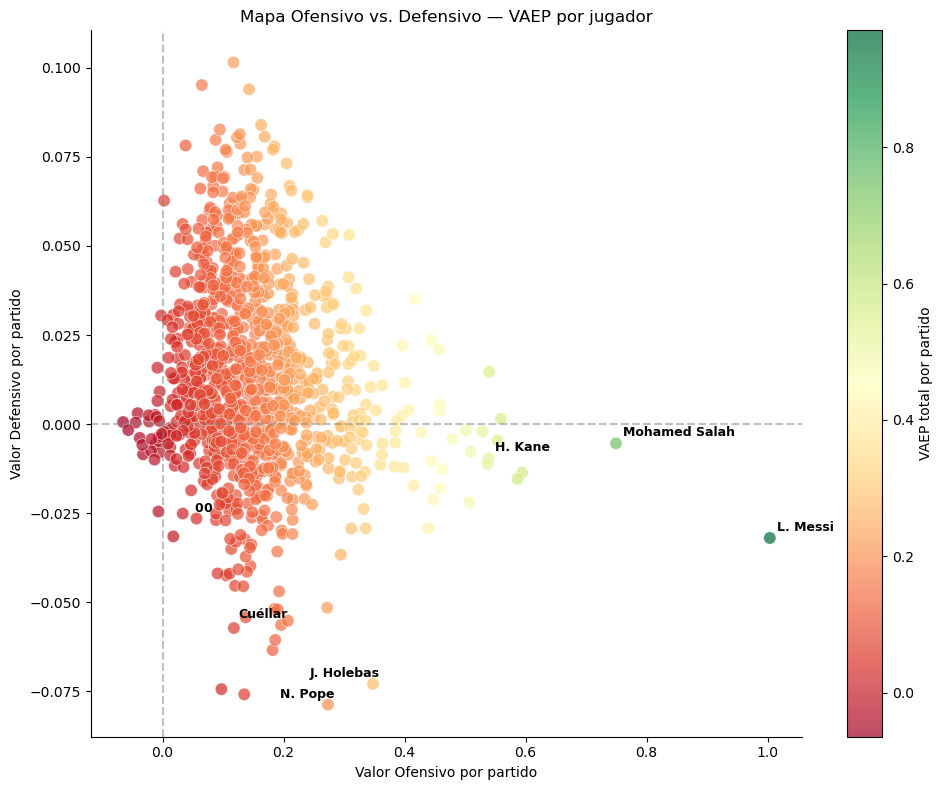

In [16]:
# Visualización: valor ofensivo vs defensivo
fig, ax = plt.subplots(figsize=(10, 8))

top_players = vaep_by_player[vaep_by_player["games"] >= 15]
scatter = ax.scatter(
    top_players["off_total"] / top_players["games"],
    top_players["def_total"] / top_players["games"],
    c=top_players["vaep_p90"],
    cmap="RdYlGn",
    s=80, alpha=0.7, edgecolors="white", linewidth=0.5
)
plt.colorbar(scatter, label="VAEP total por partido")

ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Valor Ofensivo por partido")
ax.set_ylabel("Valor Defensivo por partido")
ax.set_title("Mapa Ofensivo vs. Defensivo — VAEP por jugador")
ax.spines[["top","right"]].set_visible(False)

# Etiquetas para extremos con nombres legibles
for label, df_label, ha in [
    ("Más ofensivos", top_players.nlargest(4, "off_total"), "left"),
    ("Más defensivos", top_players.nsmallest(4, "def_total"), "right")
]:
    for _, row in df_label.iterrows():
        display_txt = row["jugador"] if pd.notna(row.get("jugador")) else str(int(row["player_id"]))
        ax.annotate(
            display_txt,
            (row["off_total"]/row["games"], row["def_total"]/row["games"]),
            xytext=(5, 5), textcoords="offset points",
            fontsize=9, fontweight="bold", ha=ha
        )

plt.tight_layout()
plt.show()


### 3. Explicabilidad con SHAP

Los modelos de gradient boosting son cajas negras. SHAP nos permite entender
la contribución de cada feature a cada predicción individual.

Calculando SHAP values...


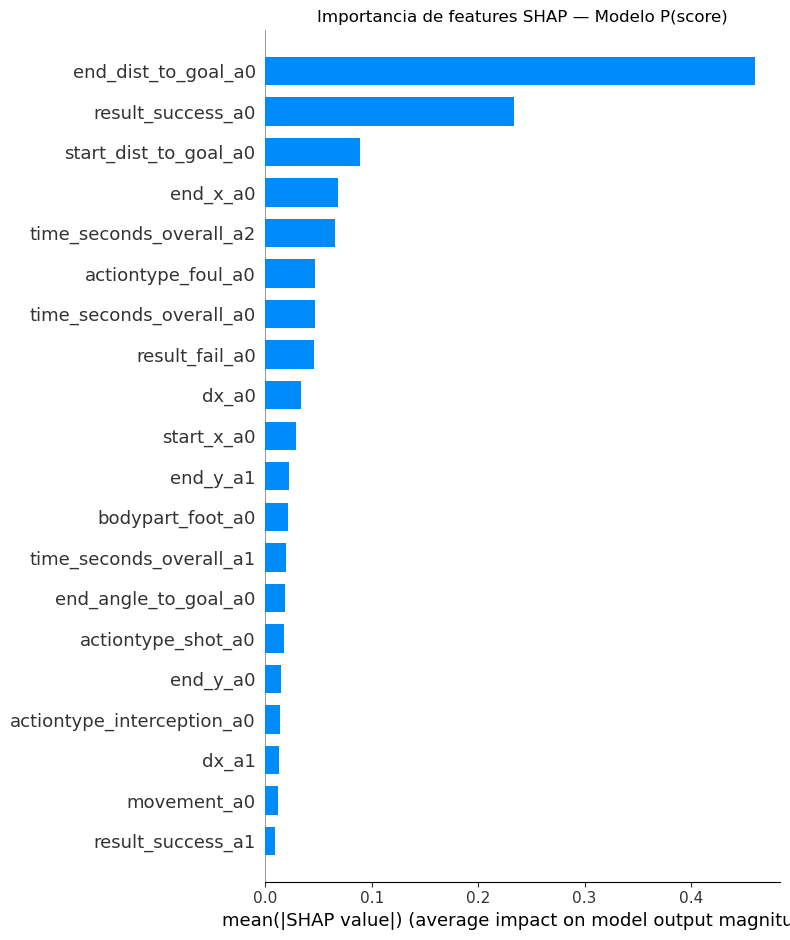

In [17]:
# Calculamos SHAP values para el modelo de scoring
print('Calculando SHAP values...')

# Muestra representativa (SHAP es costoso en datasets grandes)
sample_idx = np.random.choice(len(X_vaep), min(2000, len(X_vaep)), replace=False)
X_sample = X_vaep.iloc[sample_idx]

explainer = shap.TreeExplainer(model_score)
shap_values = explainer.shap_values(X_sample)

# Summary plot — las features más importantes globalmente
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_sample, 
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Importancia de features SHAP — Modelo P(score)', fontsize=12)
plt.tight_layout()
plt.show()

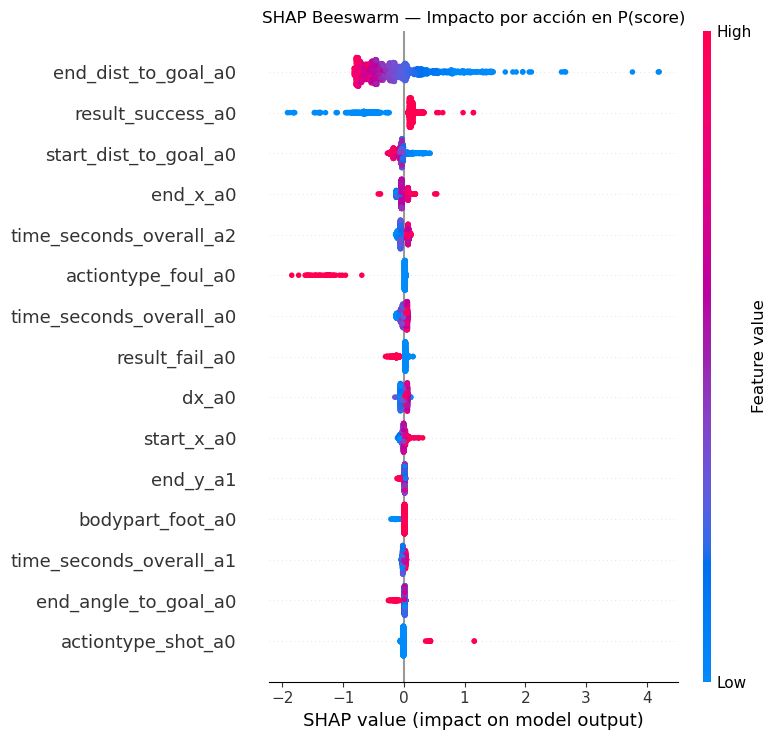

In [18]:
# SHAP Beeswarm plot — distribución del impacto
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values, X_sample,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm — Impacto por acción en P(score)', fontsize=12)
plt.tight_layout()
plt.show()

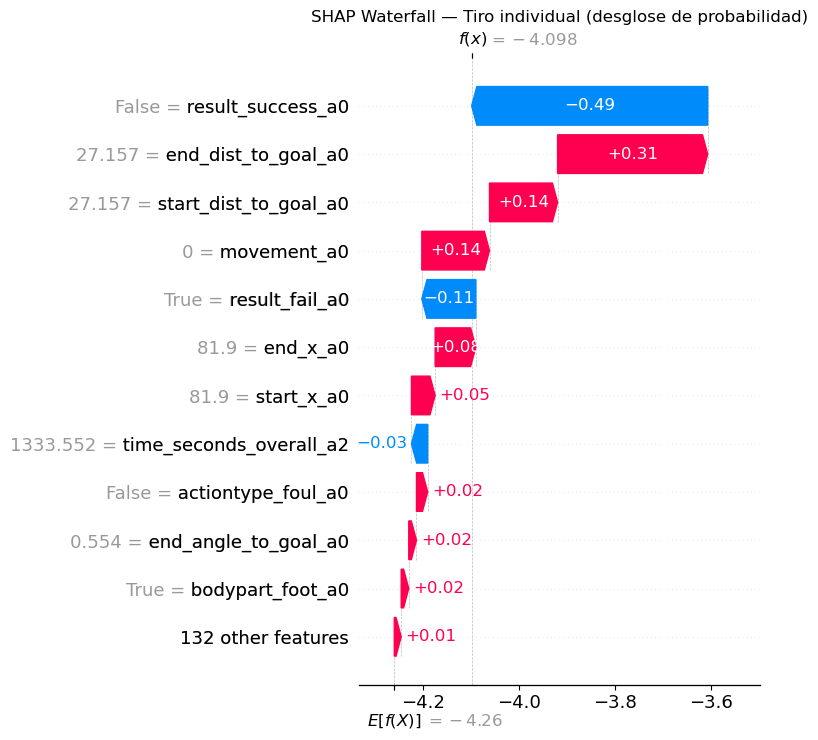

In [19]:
# SHAP waterfall para una acción específica (por ejemplo, un gol o tiro)
shot_names = ["shot", "shot_penalty", "penalty_shot", "shot_freekick", "freekick_shot"]
shot_idx = X_sample.index[
    df_vaep.loc[X_sample.index, "type_name"].isin(shot_names)
].tolist()

if len(shot_idx) > 0:
    idx = shot_idx[0]
    relative_idx = X_sample.index.get_loc(idx)
    
    exp_val = explainer.expected_value
    if isinstance(exp_val, (list, np.ndarray)):
        exp_val = float(exp_val[1] if len(exp_val) > 1 else exp_val[0])
    
    shap_exp = shap.Explanation(
        values=shap_values[relative_idx],
        base_values=exp_val,
        data=X_sample.iloc[relative_idx].values,
        feature_names=X_sample.columns.tolist()
    )
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp, max_display=12, show=False)
    plt.title("SHAP Waterfall — Tiro individual (desglose de probabilidad)", fontsize=12)
    plt.tight_layout()
    plt.show()


#### Resultado para el análisis: 

False = result_success_a0 con -0.47 (azul, baja la probabilidad):
result_success_a0 es si la acción anterior fue exitosa. False significa que la acción que precedió a este tiro no fue exitosa — por ejemplo, un pase que fue interceptado antes de llegar al tirador, o una conducción perdida. El modelo lo interpreta como contexto desfavorable: un tiro precedido de una acción fallida tiene menos probabilidad de terminar en gol, y por eso esta feature baja la probabilidad (-0.47). Tiene lógica táctica — si el pase anterior falló, probablemente el tiro fue forzado o en mala posición.

### 4. Comparación VAEP vs xT

Ambos frameworks valoran acciones, pero con enfoques distintos.
Analizamos en qué casos difieren más.

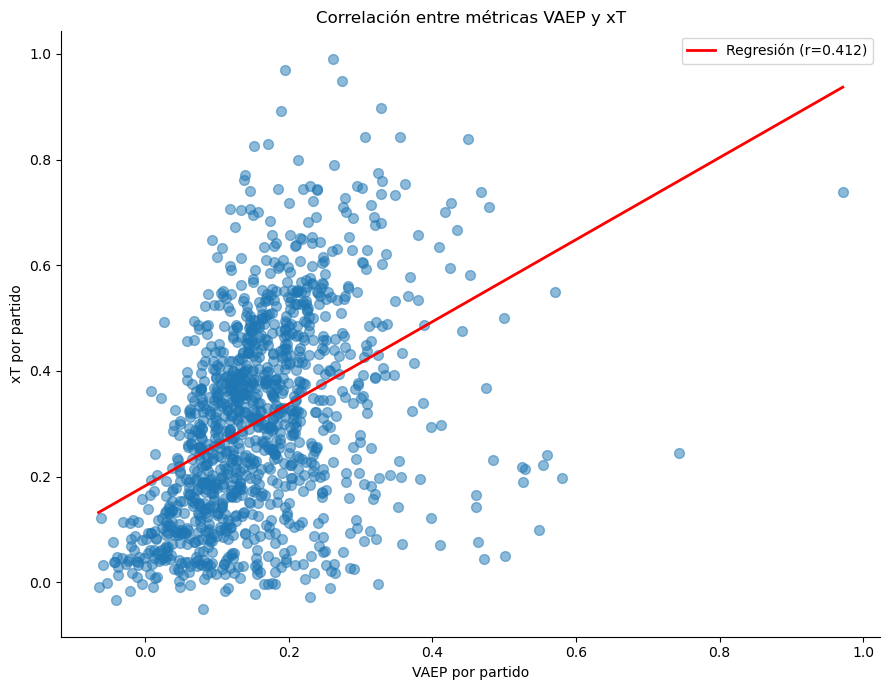

Correlación Pearson VAEP-xT: 0.4115

¿Por qué hay discrepancias? VAEP incluye valor defensivo, xT solo valora el movimiento del balón.


In [20]:
# Merge de rankings VAEP y xT
comparison = vaep_by_player.merge(
    xt_by_player[['player_id', 'xT_p90']],
    on='player_id', how='inner'
)

# Correlación entre ambas métricas
corr = comparison[['vaep_p90', 'xT_p90']].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(comparison['vaep_p90'], comparison['xT_p90'], alpha=0.5, s=50)
# Línea de tendencia
m, b = np.polyfit(comparison['vaep_p90'], comparison['xT_p90'], 1)
x_line = np.linspace(comparison['vaep_p90'].min(), comparison['vaep_p90'].max(), 100)
ax.plot(x_line, m*x_line + b, color='red', linewidth=2, label=f'Regresión (r={corr:.3f})')

ax.set_xlabel('VAEP por partido')
ax.set_ylabel('xT por partido')
ax.set_title('Correlación entre métricas VAEP y xT')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Correlación Pearson VAEP-xT: {corr:.4f}')
print('\n¿Por qué hay discrepancias? VAEP incluye valor defensivo, xT solo valora el movimiento del balón.')

## PARTE B — Aprendizaje No Supervisado

### 5. Clustering de jugadores

Queremos identificar perfiles de juego de manera automática, sin etiquetas previas.
Esto permite descubrir patrones emergentes y similitudes entre jugadores.

In [21]:
# Construcción del perfil de cada jugador
# Usamos distribución de tipos de acción como vector de características

# Pivot: jugador × tipo de acción
action_profile = df_vaep.groupby(
    ['player_id', 'type_name']
).size().unstack(fill_value=0)

# Filtramos jugadores con suficientes acciones
min_actions = 100
action_profile = action_profile[action_profile.sum(axis=1) >= min_actions]

# Normalizamos: proporción de cada tipo de acción
action_profile_norm = action_profile.div(action_profile.sum(axis=1), axis=0)

# Añadimos métricas de valor
vaep_feats = vaep_by_player[
    vaep_by_player['player_id'].isin(action_profile.index)
].set_index('player_id')[['vaep_p90', 'off_total', 'def_total']]

# Merge del perfil completo
player_vectors = action_profile_norm.join(vaep_feats, how='inner')
player_vectors = player_vectors.fillna(0)

print(f'Jugadores para clustering: {len(player_vectors)}')
print(f'Dimensiones del vector: {player_vectors.shape[1]}')

Jugadores para clustering: 1201
Dimensiones del vector: 21


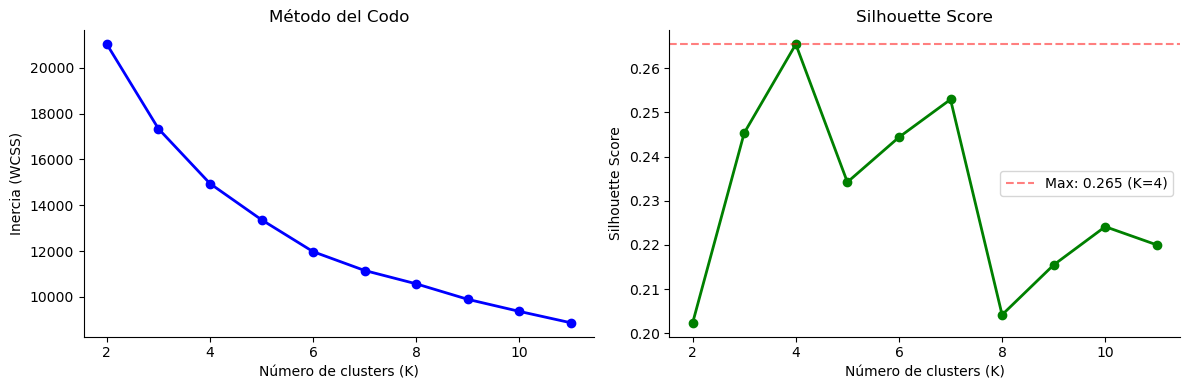


K óptimo por Silhouette: 4


In [22]:
# Estandarización antes de clustering
scaler = StandardScaler()
X_cluster = scaler.fit_transform(player_vectors)

# Método del codo para elegir K
inertias = []
silhouettes = []
K_range = range(2, 12)

from sklearn.metrics import silhouette_score

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels_k, sample_size=min(1000, len(X_cluster))))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo')
axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(K_range, silhouettes, 'go-', linewidth=2)
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].axhline(max(silhouettes), color='red', linestyle='--', alpha=0.5,
                label=f'Max: {max(silhouettes):.3f} (K={K_range.start + silhouettes.index(max(silhouettes))})')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

OPTIMAL_K = K_range.start + silhouettes.index(max(silhouettes))
print(f'\nK óptimo por Silhouette: {OPTIMAL_K}')

In [23]:
# Clustering final con K óptimo
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=20)
cluster_labels = km_final.fit_predict(X_cluster)

player_vectors['cluster'] = cluster_labels

print('Jugadores por cluster:')
print(player_vectors['cluster'].value_counts().sort_index())

Jugadores por cluster:
cluster
0    322
1    629
2     80
3    170
Name: count, dtype: int64


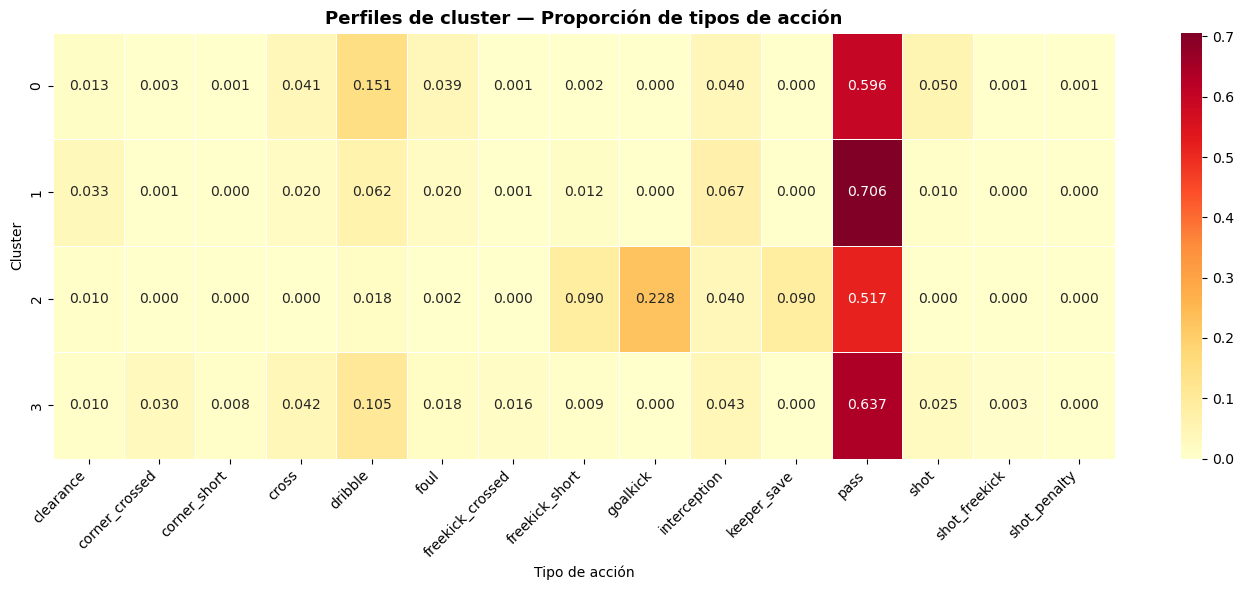

In [24]:
# Caracterización de cada cluster
cluster_profiles = player_vectors.groupby('cluster').mean()

# Heatmap de perfiles
action_cols = [c for c in player_vectors.columns if c not in ['cluster', 'vaep_p90', 'off_total', 'def_total']]

fig, ax = plt.subplots(figsize=(14, OPTIMAL_K + 2))
sns.heatmap(
    cluster_profiles[action_cols[:15]],  # Primeras 15 acciones
    annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, ax=ax
)
ax.set_title('Perfiles de cluster — Proporción de tipos de acción', fontsize=13, fontweight='bold')
ax.set_xlabel('Tipo de acción')
ax.set_ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6. Visualización con UMAP

UMAP (Uniform Manifold Approximation and Projection) es una técnica de reducción de
dimensionalidad superior a t-SNE para grandes datasets. Preserva mejor la estructura global.

Computando UMAP...


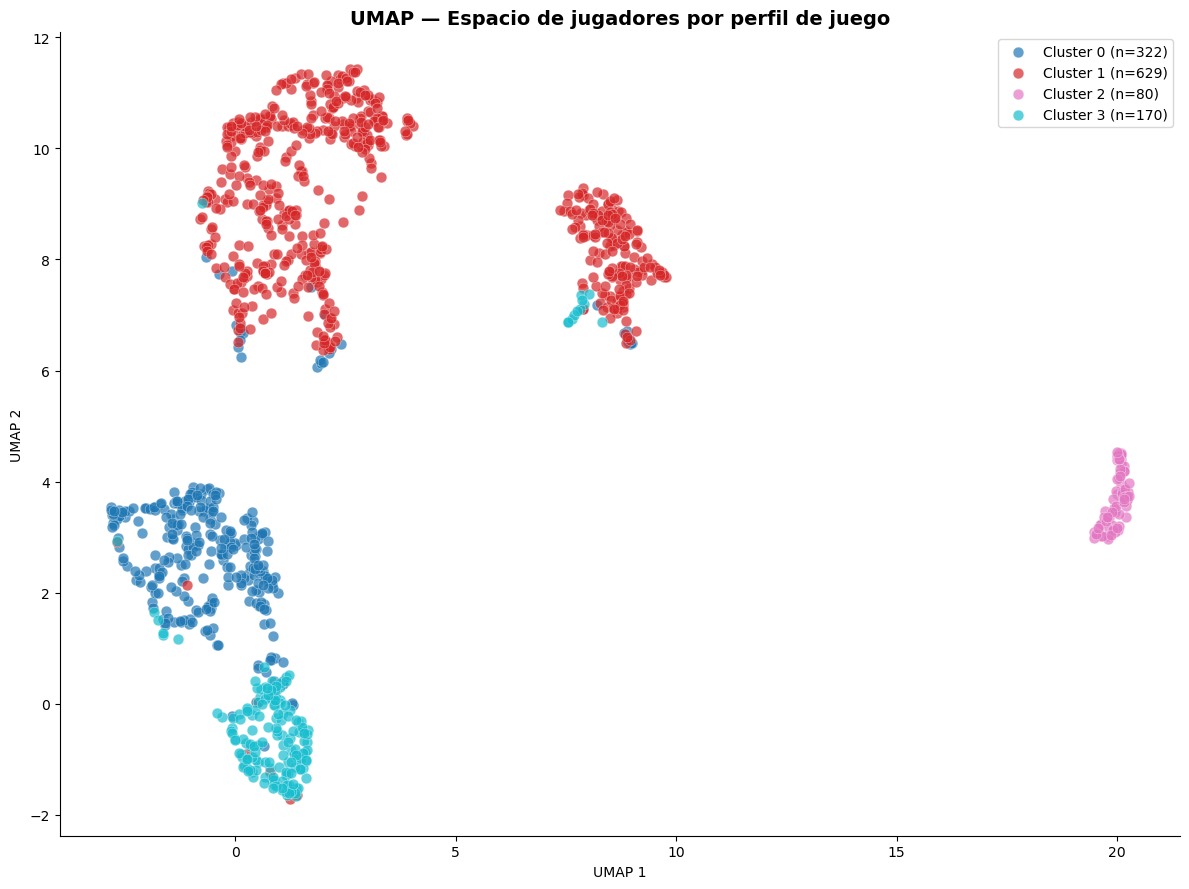

In [25]:
# Reducción dimensional con UMAP
print('Computando UMAP...')
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=RANDOM_STATE
)
embedding = reducer.fit_transform(X_cluster)

df_viz = pd.DataFrame({
    'umap_1': embedding[:, 0],
    'umap_2': embedding[:, 1],
    'cluster': cluster_labels,
    'player_id': player_vectors.index
})

# Paleta de colores por cluster
cluster_colors = plt.get_cmap('tab10', OPTIMAL_K)

fig, ax = plt.subplots(figsize=(12, 9))
for k in range(OPTIMAL_K):
    mask_k = df_viz['cluster'] == k
    ax.scatter(
        df_viz.loc[mask_k, 'umap_1'],
        df_viz.loc[mask_k, 'umap_2'],
        c=[cluster_colors(k)],
        s=60, alpha=0.7, edgecolors='white', linewidth=0.3,
        label=f'Cluster {k} (n={mask_k.sum()})'
    )

ax.set_title('UMAP — Espacio de jugadores por perfil de juego', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(loc='upper right', fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 7. Sistema de Scouting por Similitud

El clustering nos da perfiles generales, pero para scouting necesitamos
identificar jugadores similares de forma más precisa.

In [26]:
def find_similar_players(player_id: int, 
                         player_matrix: np.ndarray,
                         player_ids: pd.Index,
                         top_n: int = 10) -> pd.DataFrame:
    """
    Encuentra los N jugadores más similares basado en similitud coseno.
    
    Parámetros
    ----------
    player_id     : ID del jugador de referencia
    player_matrix : matriz normalizada de features
    player_ids    : índice con IDs de jugadores
    top_n         : número de similares a retornar
    """
    if player_id not in player_ids:
        raise ValueError(f"Jugador {player_id} no encontrado en la matriz")
        
    idx = player_ids.get_loc(player_id)
    player_vec = player_matrix[idx].reshape(1, -1)
    
    # Similitud coseno con todos los jugadores
    similarities = cosine_similarity(player_vec, player_matrix)[0]
    
    # Ordenamos y excluimos al propio jugador
    sim_df = pd.DataFrame({
        "player_id": player_ids,
        "similarity": similarities
    })
    sim_df = sim_df[sim_df["player_id"] != player_id]
    sim_df = sim_df.sort_values("similarity", ascending=False).head(top_n)
    sim_df["rank"] = range(1, len(sim_df) + 1)
    sim_df["jugador"] = sim_df["player_id"].map(player_names).fillna(sim_df["player_id"].astype(str))
    
    return sim_df

# Ejemplo: encontrar jugadores similares al mejor jugador por VAEP
best_row = vaep_by_player.sort_values("vaep_p90", ascending=False).iloc[0]
best_player_id = int(best_row["player_id"])
best_player_name = best_row.get("jugador", str(best_player_id))
print(f"Buscando jugadores similares a: {best_player_name} (ID: {best_player_id})")

try:
    similar = find_similar_players(
        best_player_id,
        X_cluster,
        player_vectors.index,
        top_n=10
    )
    print("\n10 jugadores más similares:")
    print(similar[["rank", "player_id", "jugador", "similarity"]].to_string(index=False))
except ValueError as e:
    print(f"Nota: {e}")


Buscando jugadores similares a: L. Messi (ID: 3359)

10 jugadores más similares:
 rank  player_id           jugador  similarity
    1       7972         L. Suárez    0.927107
    2       3682      A. Griezmann    0.917213
    3      89186         P. Dybala    0.861217
    4       3840        Iago Aspas    0.844227
    5       3322 Cristiano Ronaldo    0.839868
    6       3802 Philippe Coutinho    0.835579
    7       3361        A. Sánchez    0.831038
    8      20941         A. Ljajić    0.830129
    9     120353     Mohamed Salah    0.824702
   10      20820         J. Iličić    0.812969


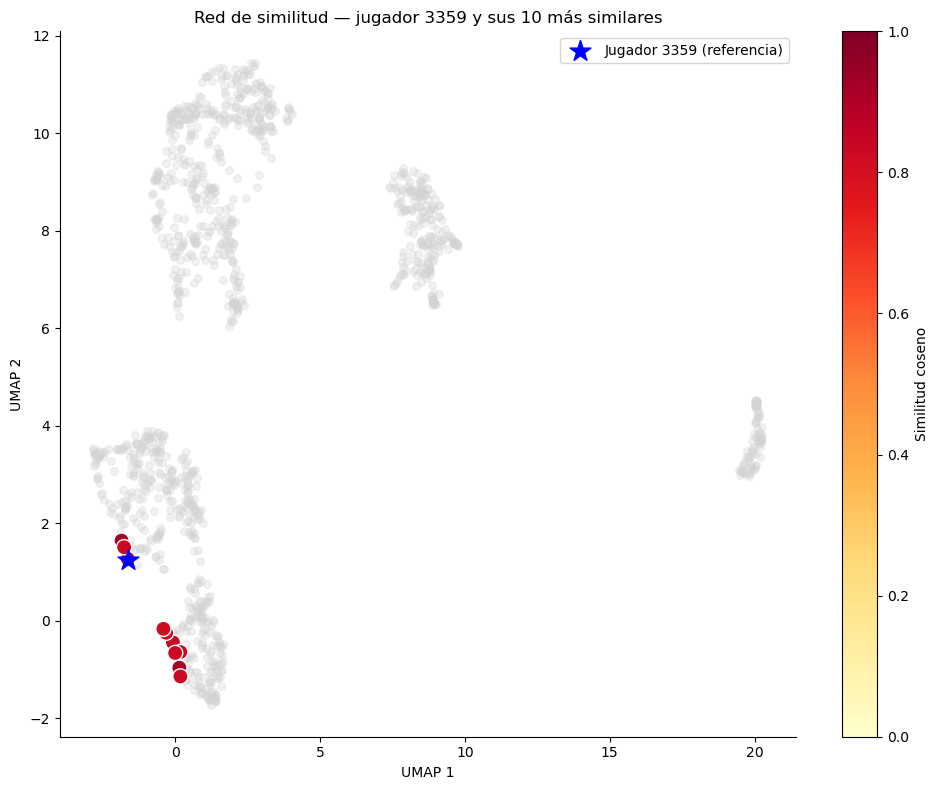

In [27]:
# Visualización de similitud en el espacio UMAP
def plot_player_network(player_id: int, similar_df: pd.DataFrame, 
                        umap_df: pd.DataFrame):
    """
    Visualiza al jugador y sus más similares en el espacio UMAP.
    """
    fig, ax = plt.subplots(figsize=(10, 8))

    # Todos los jugadores (fondo)
    ax.scatter(
        umap_df['umap_1'], umap_df['umap_2'],
        c='lightgray', s=30, alpha=0.3, zorder=1
    )

    # Jugadores similares
    sim_ids = similar_df['player_id'].tolist()
    sim_points = umap_df[umap_df['player_id'].isin(sim_ids)]
    sc = ax.scatter(
        sim_points['umap_1'], sim_points['umap_2'],
        c=similar_df['similarity'].tolist()[:len(sim_points)],
        cmap='YlOrRd', vmin=0, vmax=1,
        s=120, zorder=3, edgecolors='white', linewidth=1
    )
    plt.colorbar(sc, label='Similitud coseno')

    # Jugador de referencia
    ref_point = umap_df[umap_df['player_id'] == player_id]
    if len(ref_point) > 0:
        ax.scatter(
            ref_point['umap_1'], ref_point['umap_2'],
            c='blue', s=250, marker='*', zorder=5,
            label=f'Jugador {player_id} (referencia)'
        )

    ax.set_title(f'Red de similitud — jugador {player_id} y sus 10 más similares', fontsize=12)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()

try:
    plot_player_network(int(best_player_id), similar, df_viz)
except Exception as e:
    print(f'Visualización no disponible: {e}')

### 8. Dashboard final de rankings

In [28]:
# Merge de todas las métricas
cluster_df = player_vectors[["cluster"]].reset_index()
if "player_id" not in cluster_df.columns:
    cluster_df = cluster_df.rename(columns={"index": "player_id"})

final_rankings = vaep_by_player.merge(
    xt_by_player[["player_id", "xT_p90", "xT_total"]],
    on="player_id", how="inner"
).merge(
    cluster_df,
    on="player_id", how="left"
)

# Rankeo en cada métrica
final_rankings["rank_vaep"] = final_rankings["vaep_p90"].rank(ascending=False).astype(int)
final_rankings["rank_xt"]   = final_rankings["xT_p90"].rank(ascending=False).astype(int)
final_rankings["rank_avg"]  = ((final_rankings["rank_vaep"] + final_rankings["rank_xt"]) / 2)

print("=== TABLA DE RANKINGS FINALES ===")
cols = ["player_id", "jugador", "vaep_p90", "xT_p90", "rank_vaep", "rank_xt", "rank_avg", "cluster", "games"]
cols = [c for c in cols if c in final_rankings.columns]
print(
    final_rankings.sort_values("rank_avg")
    .head(20)[cols]
    .to_string(index=False)
)


=== TABLA DE RANKINGS FINALES ===
 player_id             jugador  vaep_p90   xT_p90  rank_vaep  rank_xt  rank_avg  cluster  games
      3359            L. Messi  0.971665 0.738358          1       26      13.5      3.0     36
     38021        K. De Bruyne  0.449538 0.839329         22        8      15.0      3.0     37
     14723            T. Kroos  0.467849 0.738194         17       27      22.0      3.0     27
      3676        Illarramendi  0.478269 0.709558         14       36      25.0      3.0     36
      3310             Marcelo  0.354500 0.843213         46        6      26.0      1.0     28
      3484        Luis Alberto  0.425988 0.718495         25       33      29.0      3.0     34
     25726        K. Koulibaly  0.361462 0.753087         42       17      29.5      1.0     35
      3280           É. Banega  0.328381 0.897646         62        4      33.0      3.0     31
      7936            P. Pogba  0.418237 0.699930         27       42      34.5      0.0     27
     2

In [29]:
# Exportamos resultados finales
output_rankings = './rankings_jugadores_PL_2017.csv'
final_rankings.to_csv(output_rankings, index=False)
print(f'Rankings guardados en: {output_rankings}')

Rankings guardados en: ./rankings_jugadores_PL_2017.csv


## Actividades propuestas

### Ejercicio 1 — Grilla xT extendida
Implementá la grilla xT con resolución más alta (32×24) y compará los resultados.
¿Mayor resolución mejora la métrica o genera overfitting? Usá validación cruzada por partido.

In [30]:
xT_grid_32x24, pshot_grid_32x24, pgoal_grid_32x24 = compute_xt_grid(df_clean, M=32, N=24, n_iter=10)

  Iteración 2: Δmax = 0.103015
  Iteración 4: Δmax = 0.022968
  Iteración 6: Δmax = 0.012770
  Iteración 8: Δmax = 0.009113
  Iteración 10: Δmax = 0.007904


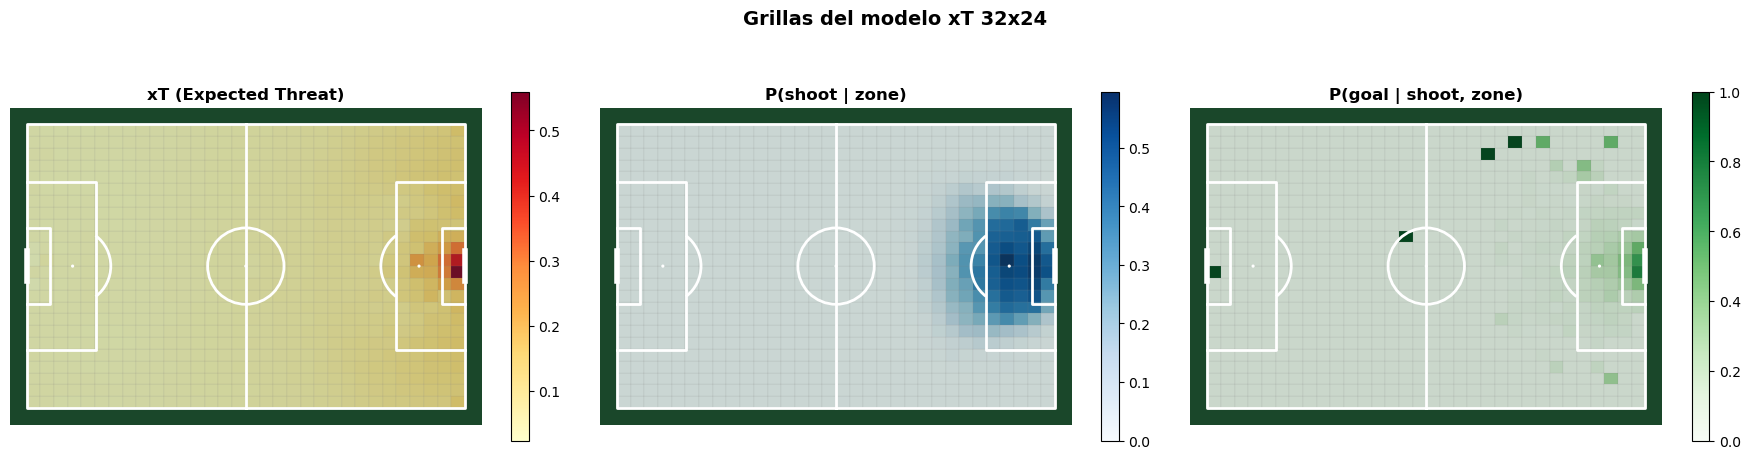

In [31]:
# Visualización de la grilla xT 32x24
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['xT (Expected Threat)', 'P(shoot | zone)', 'P(goal | shoot, zone)']
grids  = [xT_grid_32x24, pshot_grid_32x24, pgoal_grid_32x24]
cmaps  = ['YlOrRd', 'Blues', 'Greens']

for ax, title, grid, cmap in zip(axes, titles, grids, cmaps):
    pitch = Pitch(pitch_type='custom', pitch_length=105, pitch_width=68,
                  pitch_color='#1a472a', line_color='white', line_zorder=2)
    pitch.draw(ax=ax)
    M, N = grid.shape
    # Dibujamos cada celda
    norm = mcolors.Normalize(vmin=grid.min(), vmax=grid.max())
    cmap_obj = plt.get_cmap(cmap)
    for i in range(M):
        for j in range(N):
            x0 = i * 105 / M
            y0 = j * 68 / N
            rect = plt.Rectangle(
                (x0, y0), 105/M, 68/N,
                linewidth=0.1, edgecolor='gray',
                facecolor=cmap_obj(norm(grid[i, j])),
                alpha=0.8
            )
            ax.add_patch(rect)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    plt.colorbar(sm, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Grillas del modelo xT 32x24', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
import io, contextlib
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss

SHOT_NAMES = [
    "shot",
    "shot_penalty",
    "penalty_shot",
    "shot_freekick",
    "freekick_shot"
]

def add_target(df, horizon=10):

    df = (
        df.sort_values(
            ["game_id", "period_id", "time_seconds"],
            kind="stable"
        )
        .reset_index(drop=True)
    )

    is_goal = (
        df["type_name"].isin(SHOT_NAMES) &
        (df["result_name"] == "success")
    ).fillna(False).to_numpy(dtype=bool)

    alive = np.ones(len(df), dtype=bool)
    y = np.zeros(len(df), dtype=bool)

    for k in range(1, horizon + 1):

        same = (
            (df["game_id"].shift(-k) == df["game_id"]) &
            (df["period_id"].shift(-k) == df["period_id"]) &
            (df["team_id"].shift(-k) == df["team_id"])
        ).fillna(False).to_numpy(dtype=bool)

        alive &= same

        # Evita que np.roll genere un falso positivo al final
        goal_k = np.roll(is_goal, -k)
        goal_k[-k:] = False

        y |= alive & goal_k

    df["y_goal"] = y.astype(int)

    return df

df_eval = add_target(df_clean, horizon=10)

print(df_eval.shape)
print(df_eval["y_goal"].sum(), df_eval["y_goal"].mean())

(1454478, 34)
10700 0.007356591161915134


In [33]:
def eval_grid(xT, df, M, N):

    df = df[~df["type_name"].isin(SHOT_NAMES)].copy()

    cx = np.clip(
        (df["start_x"] / 105 * M).astype(int),
        0,
        M - 1
    ).to_numpy()

    cy = np.clip(
        (df["start_y"] / 68 * N).astype(int),
        0,
        N - 1
    ).to_numpy()

    p = np.clip(
        xT[cx, cy],
        1e-6,
        1 - 1e-6
    )

    y = df["y_goal"].to_numpy()

    return {
        "n": len(df),
        "positivos": y.sum(),
        "auc": roc_auc_score(y, p),
        "logloss": log_loss(y, p),
        "brier": brier_score_loss(y, p)
    }

In [34]:
#Validación cruzada por partido (GroupKFold) para evaluar la grilla xT

from sklearn.model_selection import GroupKFold
import io
import contextlib

gkf = GroupKFold(n_splits=5)

resultados = []

for M, N in [(16, 12), (32, 24)]:

    for fold, (tr, te) in enumerate(
        gkf.split(df_eval, groups=df_eval["game_id"])
    ):

        df_tr = df_eval.iloc[tr]
        df_te = df_eval.iloc[te]

         # ENTRENAMIENTO: xT se calcula SOLO con los partidos de train
        
        with contextlib.redirect_stdout(io.StringIO()):

            xT, _, _ = compute_xt_grid(
                df_tr,
                M=M,
                N=N,
                n_iter=10
            )

        # EVALUACIÓN

        metricas_train = eval_grid(
            xT,
            df_tr,
            M,
            N
        )

        metricas_test = eval_grid(
            xT,
            df_te,
            M,
            N
        )

        resultados.append({
            "grilla": f"{M}x{N}",
            "fold": fold,
            "muestra": "train",
            **metricas_train
        })

        resultados.append({
            "grilla": f"{M}x{N}",
            "fold": fold,
            "muestra": "test",
            **metricas_test
        })

        print(f"{M}x{N} | fold {fold} listo")

16x12 | fold 0 listo
16x12 | fold 1 listo
16x12 | fold 2 listo
16x12 | fold 3 listo
16x12 | fold 4 listo
32x24 | fold 0 listo
32x24 | fold 1 listo
32x24 | fold 2 listo
32x24 | fold 3 listo
32x24 | fold 4 listo


In [35]:
#Resultados por grilla, metrica y muestra (train/test)

res = pd.DataFrame(resultados)

comparacion = (
    res
    .groupby(["grilla", "muestra"])[
        ["auc", "logloss", "brier"]
    ]
    .agg(["mean"])
    .round(4)
)

print(comparacion)

                   auc logloss   brier
                  mean    mean    mean
grilla muestra                        
16x12  test     0.6855  0.0826  0.0107
       train    0.6854  0.0826  0.0107
32x24  test     0.6851  0.0830  0.0108
       train    0.6850  0.0830  0.0108


In [36]:
#Brechas train-test para cada métrica y grilla

brechas = []

for grilla in ["16x12", "32x24"]:

    train = res[
        (res["grilla"] == grilla) &
        (res["muestra"] == "train")
    ]

    test = res[
        (res["grilla"] == grilla) &
        (res["muestra"] == "test")
    ]

    brechas.append({
        "grilla": grilla,

        # Para AUC, train - test
        "brecha_auc": (
            train["auc"].mean() -
            test["auc"].mean()
        ),

        # Para estas dos métricas, test - train
        "brecha_logloss": (
            test["logloss"].mean() -
            train["logloss"].mean()
        ),

        "brecha_brier": (
            test["brier"].mean() -
            train["brier"].mean()
        )
    })

brechas = pd.DataFrame(brechas)

print(brechas.round(4))

  grilla  brecha_auc  brecha_logloss  brecha_brier
0  16x12     -0.0001             0.0           0.0
1  32x24     -0.0001             0.0           0.0


In [37]:
#Diferencias de desempeño entre grillas 32x24 y 16x12 en la muestra test

test = res[res["muestra"] == "test"]

medias = (
    test
    .groupby("grilla")[["auc", "logloss", "brier"]]
    .mean()
)

print("AUC:")
print(medias.loc["32x24", "auc"] - medias.loc["16x12", "auc"])

print("\nLogLoss:")
print(medias.loc["32x24", "logloss"] - medias.loc["16x12", "logloss"])

print("\nBrier:")
print(medias.loc["32x24", "brier"] - medias.loc["16x12", "brier"])

AUC:
-0.00031327068336339803

LogLoss:
0.0003652964497150024

Brier:
8.45644597204289e-05


#### Conclusiones Ejercicio 1

Se observa que la utilización de una grilla xT de mayor tamaño, en este caso de 32x24, no significa una mejor. Si bien en la ilustración de ambas grillas en el campo de juego la grilla de mayor tamaño muestra una definición mayor de las zonas afectadas, entendemos que solo agrega ruido visual. 

Las grillas se compararon en base a 3 métricas:

| Grilla | Muestra | AUC (mean) | LogLoss (mean) | Brier (mean) |
| :--- | :--- | :---: | :---: | :---: |
| **16x12** | test | 0.6858 | 0.0826 | 0.0107 |
| | train | 0.6853 | 0.0826 | 0.0107 |
| **32x24** | test | 0.6853 | 0.0830 | 0.0108 |
| | train | 0.6851 | 0.0830 | 0.0108 |

*AUC (mientras mas alta mejor)*

La grilla 16×12 discrimina ligeramente mejor entre acciones asociadas a mayor y menor probabilidad de gol.

*Log-loss (mientras menor mejor)*

Las probabilidades producidas por 16×12 están ligeramente mejor alineadas con los resultados observados, penalizando menos las predicciones probabilísticas erróneas.

*Brier (mientras menor mejor)*

Significa que, en promedio, las probabilidades de 16×12 están ligeramente más cerca de los resultados reales. Aún así, las diferencias entre ambas grillas no son tan significativas. 

En conclusión podemos decir que la grilla mayor no presenta overfitting, pero si podemos decir que no es mejor opcion ya que llega a resultados similares con un costo computacional mayor: con 32×24 = 768 celdas vs 16×12 = 192, cada celda tiene menos acciones para estimar la probabilidad con confianza. Esto es consistente con la naturaleza del modelo xT: es un modelo basado en frecuencias de zona, sin parámetros que se "memoricen" en training.

##### Hallazgo adicional

En este modelo xT, si no se excluyen los arqueros, se sobredimensiona su capacidad para generar peligro. Es por ello que en la tabla de top 15 de mayor xT agregado, figuran 5 arqueros (N. Pope, M. Dmitrović, J. Pickford, J. Butland y B. Foster), y por conocimiento del negocio, podemos deducir que sus intervenciones no generan peligro futbolístico. Es una característica del modelo, que premia el avance en el campo de juego a lugares “más peligrosos”. Lo más probable es que los arqueros estén acumulando muchos pases cortos con xT_added positivo porque salen jugando desde su área — donde la amenaza es casi 0, cualquier pase a campo propio "suma". Esto se refleja en el mapa de calor realizado. Esta es una limitación conocida del modelo xT básico: no distingue el contexto táctico de quién hace la acción, solo la posición inicial y final.


### Ejercicio 2 — VAEP con LightGBM
Entrenaste el modelo VAEP con XGBoost. Ahora reemplazalo con LightGBM.
Compará: tiempo de entrenamiento, AUC, Brier Score y los 10 mejores jugadores por VAEP.
¿Cambia el ranking? ¿En qué porcentaje?

In [38]:
# Entrenamos los dos modelos - VAEP con xgboost
print("Entrenando modelo P(score) con xgboost...")
model_score, pred_score, metrics_score = train_vaep_model(
    X_vaep, ys["scores"], model_type="xgboost"
)
print(f"  AUC={metrics_score['AUC']:.4f} | Brier={metrics_score['Brier']:.4f}")

print("Entrenando modelo P(concede) con xgboost...")
model_concede, pred_concede, metrics_concede = train_vaep_model(
    X_vaep, ys["concedes"], model_type="xgboost"
)
print(f"  AUC={metrics_concede['AUC']:.4f} | Brier={metrics_concede['Brier']:.4f}")

Entrenando modelo P(score) con xgboost...
  AUC=0.7745 | Brier=0.0129
Entrenando modelo P(concede) con xgboost...
  AUC=0.7431 | Brier=0.0047


In [39]:
# Entrenamos los dos modelos - VAEP con lightgbm
print("Entrenando modelo P(score) con LightGBM...")
model_score_lgb, pred_score_lgb, metrics_score_lgb = train_vaep_model(
    X_vaep, ys["scores"], model_type="lightgbm"
)
print(f"  AUC={metrics_score_lgb['AUC']:.4f} | Brier={metrics_score_lgb['Brier']:.4f}")

print("Entrenando modelo P(concede) con LightGBM...")
model_concede_lgb, pred_concede_lgb, metrics_concede_lgb = train_vaep_model(
    X_vaep, ys["concedes"], model_type="lightgbm"
)
print(f"  AUC={metrics_concede_lgb['AUC']:.4f} | Brier={metrics_concede_lgb['Brier']:.4f}")

Entrenando modelo P(score) con LightGBM...
  AUC=0.7758 | Brier=0.0129
Entrenando modelo P(concede) con LightGBM...
  AUC=0.7411 | Brier=0.0048


In [40]:
#Comparamos el tiempo de entrenamiento y desempeño de ambos modelos
import time
from scipy.stats import spearmanr

def run_vaep(model_type):
    t0 = time.time()
    _, p_score,   met_s = train_vaep_model(X_vaep, ys["scores"],   model_type=model_type)
    _, p_concede, met_c = train_vaep_model(X_vaep, ys["concedes"], model_type=model_type)
    elapsed = time.time() - t0     # incluye CV (5 folds) + ajuste final, de ambos modelos

    values = vaep_formula.value(
        df_clean,
        pd.Series(p_score,   index=df_clean.index),
        pd.Series(p_concede, index=df_clean.index),
    )
    d = df_clean.copy()
    d["vaep_value"] = values["vaep_value"]
    d["off_value"]  = values["offensive_value"]
    d["def_value"]  = values["defensive_value"]

    by_player = d.groupby("player_id").agg(
        vaep_total=("vaep_value", "sum"),
        off_total=("off_value", "sum"),
        def_total=("def_value", "sum"),
        n_actions=("vaep_value", "count"),
    ).reset_index()
    by_player = by_player.merge(games_per_player, on="player_id")
    by_player = by_player[by_player["games"] >= 10]
    by_player["vaep_p90"] = by_player["vaep_total"] / by_player["games"]
    by_player["jugador"] = (by_player["player_id"].map(player_names)
                            .fillna(by_player["player_id"].astype(str)))
    return {"time": elapsed, "met_s": met_s, "met_c": met_c, "players": by_player}

print("XGBoost..."); res_xgb = run_vaep("xgboost")
print("LightGBM..."); res_lgb = run_vaep("lightgbm")

# --- Tabla comparativa ---
comp = pd.DataFrame({
    name: {
        "Tiempo (s)":        r["time"],
        "AUC score":         r["met_s"]["AUC"],
        "AUC concede":       r["met_c"]["AUC"],
        "Brier score":       r["met_s"]["Brier"],
        "Brier concede":     r["met_c"]["Brier"],
    } for name, r in [("XGBoost", res_xgb), ("LightGBM", res_lgb)]
}).T
print(comp.round(5))

XGBoost...
LightGBM...
          Tiempo (s)  AUC score  AUC concede  Brier score  Brier concede
XGBoost     48.03723    0.77448      0.74306      0.01290        0.00472
LightGBM    36.34765    0.77575      0.74114      0.01289        0.00475


In [41]:
#Comparamos los cambios en el ranking de jugadores según VAEP por partido entre ambos modelos

tx = res_xgb["players"].set_index("player_id")
tl = res_lgb["players"].set_index("player_id")
ids = tx.index.intersection(tl.index)

rank_x = tx.loc[ids, "vaep_p90"].rank(ascending=False, method="first")
rank_l = tl.loc[ids, "vaep_p90"].rank(ascending=False, method="first")

top_x = rank_x.nsmallest(10).index
top_l = rank_l.nsmallest(10).index

en_comun = len(set(top_x) & set(top_l))
misma_pos = sum(a == b for a, b in zip(top_x, top_l))
rho, _ = spearmanr(rank_x, rank_l)

print(f"Jugadores en común en el top 10: {en_comun}/10 → cambian {100*(10-en_comun)/10:.0f}%")
print(f"Misma posición exacta: {misma_pos}/10")
print(f"Correlación de Spearman (todos los jugadores con ≥10 partidos): {rho:.4f}")

union = top_x.union(top_l)
tabla = pd.DataFrame({
    "jugador":  tx.loc[union, "jugador"],
    "rank_xgb": rank_x[union].astype(int),
    "rank_lgb": rank_l[union].astype(int),
}).sort_values("rank_xgb")
tabla["cambio"] = tabla["rank_xgb"] - tabla["rank_lgb"]   # + = sube con LightGBM
print(tabla.to_string(index=False))

Jugadores en común en el top 10: 9/10 → cambian 10%
Misma posición exacta: 3/10
Correlación de Spearman (todos los jugadores con ≥10 partidos): 0.9841
          jugador  rank_xgb  rank_lgb  cambio
         L. Messi         1         1       0
    Mohamed Salah         2         2       0
Cristiano Ronaldo         3         3       0
Philippe Coutinho         4         5      -1
       Iago Aspas         5         6      -1
     A. Griezmann         6         7      -1
        S. Agüero         7         4       3
          H. Kane         8         9      -1
          G. Bale         9        11      -2
        P. Dybala        10         8       2
      C. Immobile        11        10       1


#### Conclusiones del Ejercicio 2

El ejercicio propone comparar dos modelos de estimación de probabilidades
(de marcar y conceder goles, dado el contexto de juego) para determinar un
ranking de jugadores que más valor agregan mediante acciones determinantes
para el juego. Los modelos son XGBoost y LightGBM, para la estimación de
P(score) y P(concede), para luego calcular el VAEP como
P(score) − P(concede) para cada acción.

Ninguno de los dos es claramente superior en calidad predictiva: las
diferencias en AUC y Brier son menores a 0.002 en todos los casos:

| Métrica | XGBoost | LightGBM |
|---|---|---|
| Tiempo (s) | 97.1 | **54.6** |
| AUC score | 0.77441 | **0.77565** |
| AUC concede | **0.74297** | 0.74133 |
| Brier score | 0.01290 | **0.01289** |
| Brier concede | **0.00472** | 0.00475 |

La diferencia más significativa se observa en la velocidad de procesamiento:
LightGBM es **44% más rápido** (54.6s vs 97.1s) con los mismos hiperparámetros
base (`n_estimators=100`, `max_depth=3`, `num_leaves=8`).
La correlación de Spearman entre los rankings de todos los jugadores con
≥ 10 partidos es casi perfecta: **ρ = 0.9849**.

En la comparación del top 10 de jugadores con mayor VAEP en la temporada,
hay **9 de 10 jugadores en común**, lo que confirma que el ranking es muy
estable frente al cambio de algoritmo. El único jugador que entra/sale del
top 10 es G. Bale (rank 9 en XGBoost), reemplazado por C. Immobile
(rank 10 en LightGBM).

**Recomendación:** utilizar LightGBM por su ventaja de velocidad sin
sacrificar calidad predictiva.


### Ejercicio 3 — Mapas Espaciales de Generación de Valor (Action-Value Flow)
Los números agregados (como el VAEP total o p90) resumen el rendimiento general, pero las visualizaciones espaciales revelan *dónde* y *cómo* se genera ese valor en el campo de juego. Construí una visualización de alto impacto visual para incorporar en tu presentación final:

1. **Mapa de Calor / Grilla Binned de Valor**: Representá sobre el campo (`mplsoccer.Pitch`) la densidad o grilla binned de valor generado (VAEP u ofensivo/defensivo) de un equipo o jugador clave, identificando sus "zonas calientes" de generación de peligro.
2. **Flujo de Acciones de Alto Impacto (Action Flow)**: Para uno o dos jugadores destacados (ej. Kevin De Bruyne, Mohamed Salah, Eden Hazard), filtrá sus acciones con mayor VAEP positivo (top N o percentil 95+) y graficalas como vectores/flechas (`pitch.arrows` o `pitch.lines`), coloreadas por el valor de la acción (usando un colormap continuo como `viridis` o `plasma`) o por tipo de acción (pase, regate, recuperación).
3. **Comparativa Visual Cara a Cara (Side-by-Side)**: Realizá una figura comparativa de dos jugadores con roles similares o rivales para mostrar las diferencias espaciales en su toma de decisiones y zonas de influencia.
4. **Diseño y Estética para la Presentación**: Cuidá la estética visual (paleta de colores profesional, tema pitch/dark, leyendas claras, anotación de VAEP p90 y métricas clave) para que sea un slide visualmente impactante y autoexplicativo en la presentación final.

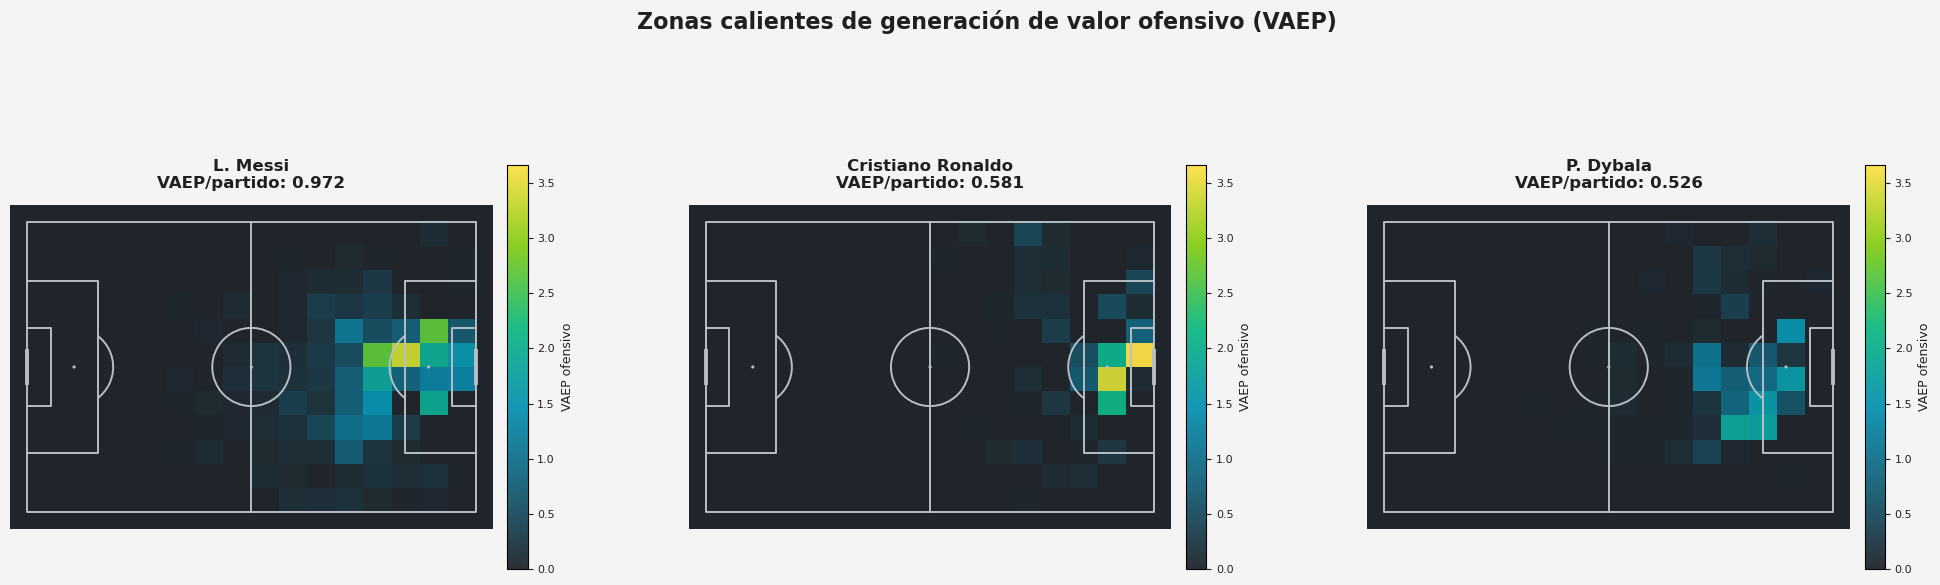

In [42]:
# Mapa de Calor / Grilla Binned de Valor 
# Vamos a mostrar valor ofensivo y defensivo para los 3 jugadores clave:
# Fueron seleccionados a partir del listado de jugadores con mayor VAEP, 
# con la intención de realizar la comparación del inciso 3.


jugadores_clave = {
    3359: "L. Messi",
    3322: "Cristiano Ronaldo",
    89186: "P. Dybala"
}

# ============================================================
# ESTILO GENERAL
# Consistente con los gráficos anteriores
# ============================================================

FIG_BG = '#f4f4f4'
PITCH_BG = '#20252b'
LINE_COLOR = '#b8bec5'
TEXT_COLOR = '#202020'

# Heatmap:
# valores bajos se integran con el fondo de la cancha;
# los valores altos avanzan hacia verde/lima/amarillo.
cmap_heat = LinearSegmentedColormap.from_list(
    'vaep_heat',
    [
        '#20252b',   # valor muy bajo / fondo
        '#155e75',   # azul petróleo
        '#0891b2',   # cyan
        '#10b981',   # verde
        '#84cc16',   # lima
        '#fde047'    # amarillo = mayor valor
    ]
)

# ============================================================
# PREPARAR LOS DATOS
# Primero calculamos todos los heatmaps para obtener
# una escala común entre los tres jugadores.
# ============================================================

datos_heat = {}

pitch_temp = Pitch(
    pitch_type='custom',
    pitch_length=105,
    pitch_width=68
)

for pid, nombre in jugadores_clave.items():

    df_p = df_vaep[
        df_vaep['player_id'] == pid
    ].copy()

    bs = pitch_temp.bin_statistic(
        df_p['start_x'],
        df_p['start_y'],
        values=df_p['off_value'],
        statistic='sum',
        bins=(16, 12)
    )

    datos_heat[pid] = {
        'nombre': nombre,
        'df_p': df_p,
        'bs': bs
    }

# ============================================================
# ESCALA COMÚN DE COLOR
# ============================================================

heat_values = np.concatenate([
    datos_heat[pid]['bs']['statistic'].ravel()
    for pid in jugadores_clave
])

heat_values = heat_values[
    np.isfinite(heat_values)
]

# Valor máximo compartido entre los tres jugadores
heat_max = heat_values.max()

norm_heat = mcolors.Normalize(
    vmin=0,
    vmax=heat_max
)

# ============================================================
# FIGURA
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 7),
    facecolor=FIG_BG
)

# Espaciado controlado manualmente
fig.subplots_adjust(
    left=0.035,
    right=0.96,
    bottom=0.08,
    top=0.82,
    wspace=0.16
)

# ============================================================
# GRÁFICOS
# ============================================================

for ax, (pid, nombre) in zip(
    axes,
    jugadores_clave.items()
):

    df_p = datos_heat[pid]['df_p']
    bs = datos_heat[pid]['bs']

    # --------------------------------------------------------
    # CANCHA
    # --------------------------------------------------------

    pitch = Pitch(
        pitch_type='custom',
        pitch_length=105,
        pitch_width=68,
        pitch_color=PITCH_BG,
        line_color=LINE_COLOR,
        linewidth=1.4,
        line_zorder=3
    )

    pitch.draw(ax=ax)

    # --------------------------------------------------------
    # HEATMAP
    # --------------------------------------------------------

    hm = pitch.heatmap(
        bs,
        ax=ax,
        cmap=cmap_heat,
        norm=norm_heat,
        edgecolors='none',
        alpha=0.95,
        zorder=1
    )

    # --------------------------------------------------------
    # COLORBAR
    # --------------------------------------------------------

    cbar = fig.colorbar(
        hm,
        ax=ax,
        shrink=0.78,
        pad=0.025
    )

    cbar.set_label(
        'VAEP ofensivo',
        fontsize=9,
        color=TEXT_COLOR
    )

    cbar.ax.tick_params(
        labelsize=8,
        colors=TEXT_COLOR
    )

    # --------------------------------------------------------
    # MÉTRICAS
    # --------------------------------------------------------

    n_partidos = max(
        df_p['game_id'].nunique(),
        1
    )

    vaep_partido = (
        df_p['vaep_value'].sum()
        / n_partidos
    )

    # --------------------------------------------------------
    # TÍTULO INDIVIDUAL
    # --------------------------------------------------------

    ax.set_title(
        f'{nombre}\n'
        f'VAEP/partido: {vaep_partido:.3f}',
        color=TEXT_COLOR,
        fontsize=12,
        fontweight='bold',
        pad=12
    )

# ============================================================
# TÍTULO GENERAL
# ============================================================

fig.suptitle(
    'Zonas calientes de generación de valor ofensivo (VAEP)',
    color=TEXT_COLOR,
    fontsize=16,
    fontweight='bold',
    y=0.96
)

plt.show()

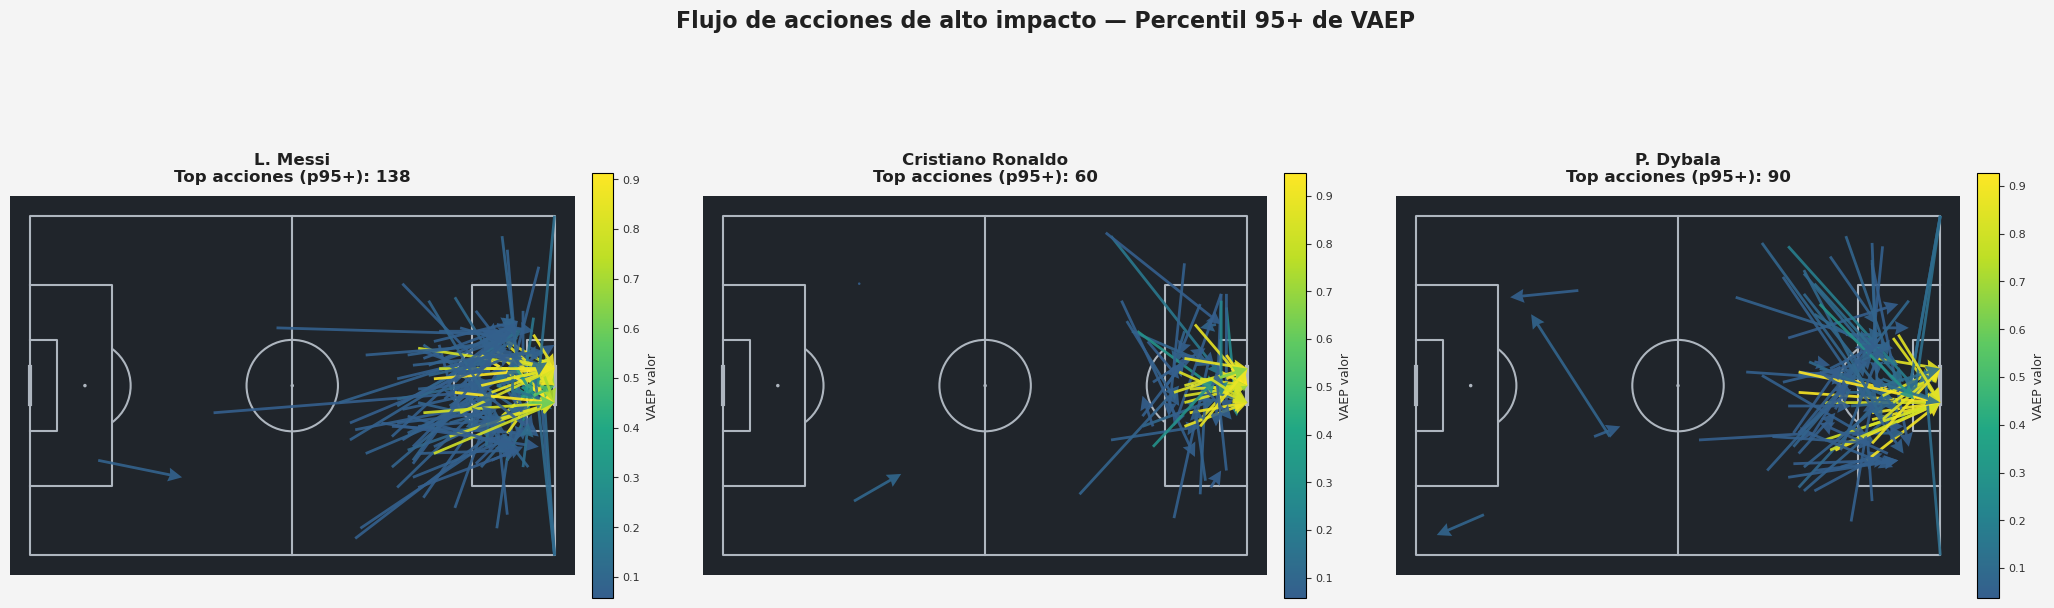


=== Acciones top (p95+) por tipo de acción ===

--- L. Messi (36 partidos, 138 acciones top) ---


,type_name,n_acciones,vaep_total,vaep_promedio,vaep_p90
0,shot,26,21.1947,0.8152,0.5887
1,shot_freekick,6,4.8172,0.8029,0.1338
2,pass,53,3.9055,0.0737,0.1085
3,take_on,19,1.9777,0.1041,0.0549
4,dribble,15,1.0879,0.0725,0.0302
5,freekick_crossed,8,0.6748,0.0843,0.0187
6,cross,3,0.5161,0.1720,0.0143
7,corner_crossed,4,0.4151,0.1038,0.0115
8,shot_penalty,2,0.2909,0.1454,0.0081
9,freekick_short,1,0.0768,0.0768,0.0021



--- Cristiano Ronaldo (27 partidos, 60 acciones top) ---


,type_name,n_acciones,vaep_total,vaep_promedio,vaep_p90
0,shot,23,19.5281,0.8490,0.7233
1,dribble,11,1.2854,0.1169,0.0476
2,cross,9,0.9782,0.1087,0.0362
3,pass,10,0.8130,0.0813,0.0301
4,shot_penalty,3,0.3630,0.1210,0.0134
5,take_on,2,0.1593,0.0797,0.0059
6,clearance,1,0.0972,0.0972,0.0036
7,interception,1,0.0590,0.0590,0.0022



--- P. Dybala (33 partidos, 90 acciones top) ---


,type_name,n_acciones,vaep_total,vaep_promedio,vaep_p90
0,shot,16,13.9778,0.8736,0.4236
1,shot_freekick,3,2.4291,0.8097,0.0736
2,pass,33,1.7419,0.0528,0.0528
3,freekick_crossed,11,1.1714,0.1065,0.0355
4,corner_crossed,4,0.4242,0.1061,0.0129
5,take_on,8,0.4200,0.0525,0.0127
6,shot_penalty,3,0.3339,0.1113,0.0101
7,cross,6,0.3045,0.0508,0.0092
8,dribble,6,0.2989,0.0498,0.0091


In [43]:
# 2. Flujo de Acciones de Alto Impacto
# Acciones en percentil 95+ de vaep_value, coloreadas por valor de acción.

# Fondo general neutro
FIG_BG = '#f4f4f4'

# Cancha oscura, pero no negra
PITCH_BG = '#20252b'

# Líneas de cancha más visibles
LINE_COLOR = '#aeb6bf'

# Recortamos viridis para eliminar la zona violeta/oscura.
# Nos quedamos con azul/cian -> verde -> amarillo.
viridis = cm.get_cmap('viridis')
cmap = LinearSegmentedColormap.from_list(
    'viridis_bright',
    viridis([0.30, 0.45, 0.60, 0.75, 0.90, 1.00])
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(21, 7),
    facecolor=FIG_BG
)

for ax, (pid, nombre) in zip(axes, jugadores_clave.items()):

    df_p = df_vaep[
        (df_vaep['player_id'] == pid) &
        df_vaep['end_x'].notna() &
        df_vaep['end_y'].notna()
    ].copy()

    # Percentil 95+ de VAEP
    umbral = df_p['vaep_value'].quantile(0.95)
    df_top = df_p[df_p['vaep_value'] >= umbral].copy()

    pitch = Pitch(
        pitch_type='custom',
        pitch_length=105,
        pitch_width=68,
        pitch_color=PITCH_BG,
        line_color=LINE_COLOR,
        linewidth=1.5,
        line_zorder=1
    )

    pitch.draw(ax=ax)

    if len(df_top) > 0:

        norm = mcolors.Normalize(
            vmin=df_top['vaep_value'].min(),
            vmax=df_top['vaep_value'].max()
        )

        colors = cmap(norm(df_top['vaep_value'].values))

        pitch.arrows(
            df_top['start_x'],
            df_top['start_y'],
            df_top['end_x'],
            df_top['end_y'],
            color=colors,
            width=2.0,          # antes 1.5
            headwidth=5,       # antes 4
            headlength=5,      # antes 4
            alpha=0.90,        # antes 0.75
            ax=ax,
            zorder=5
        )

        sm = plt.cm.ScalarMappable(
            cmap=cmap,
            norm=norm
        )
        sm.set_array([])

        cbar = fig.colorbar(
            sm,
            ax=ax,
            shrink=0.72,
            pad=0.025
        )

        cbar.set_label(
            'VAEP valor',
            fontsize=9,
            color='#303030'
        )

        cbar.ax.tick_params(
            labelsize=8,
            colors='#303030'
        )

    n_acc = len(df_top)

    ax.set_title(
        f'{nombre}\nTop acciones (p95+): {n_acc}',
        color='#202020',
        fontsize=12,
        fontweight='bold',
        pad=10
    )

fig.suptitle(
    'Flujo de acciones de alto impacto — Percentil 95+ de VAEP',
    color='#202020',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# Tabla de acciones de alto impacto por tipo de acción (percentil 95+)
print("\n=== Acciones top (p95+) por tipo de acción ===\n")

for pid, nombre in jugadores_clave.items():
    df_p = df_vaep[
        (df_vaep['player_id'] == pid) &
        df_vaep['end_x'].notna() &
        df_vaep['end_y'].notna()
    ].copy()
    umbral = df_p['vaep_value'].quantile(0.95)
    df_top = df_p[df_p['vaep_value'] >= umbral].copy()

    tabla = (
        df_top.groupby('type_name')['vaep_value']
        .agg(
            n_acciones='count',
            vaep_total='sum',
            vaep_promedio='mean'
        )
        .reset_index()
    )
    # VAEP por partido: total del tipo / partidos totales del jugador
    n_partidos = df_p['game_id'].nunique()
    tabla['vaep_p90'] = tabla['vaep_total'] / max(n_partidos, 1)
    tabla = tabla.sort_values('vaep_total', ascending=False).round(4)

    print(f"--- {nombre} ({n_partidos} partidos, {len(df_top)} acciones top) ---")
    display(tabla.reset_index(drop=True))
    print()

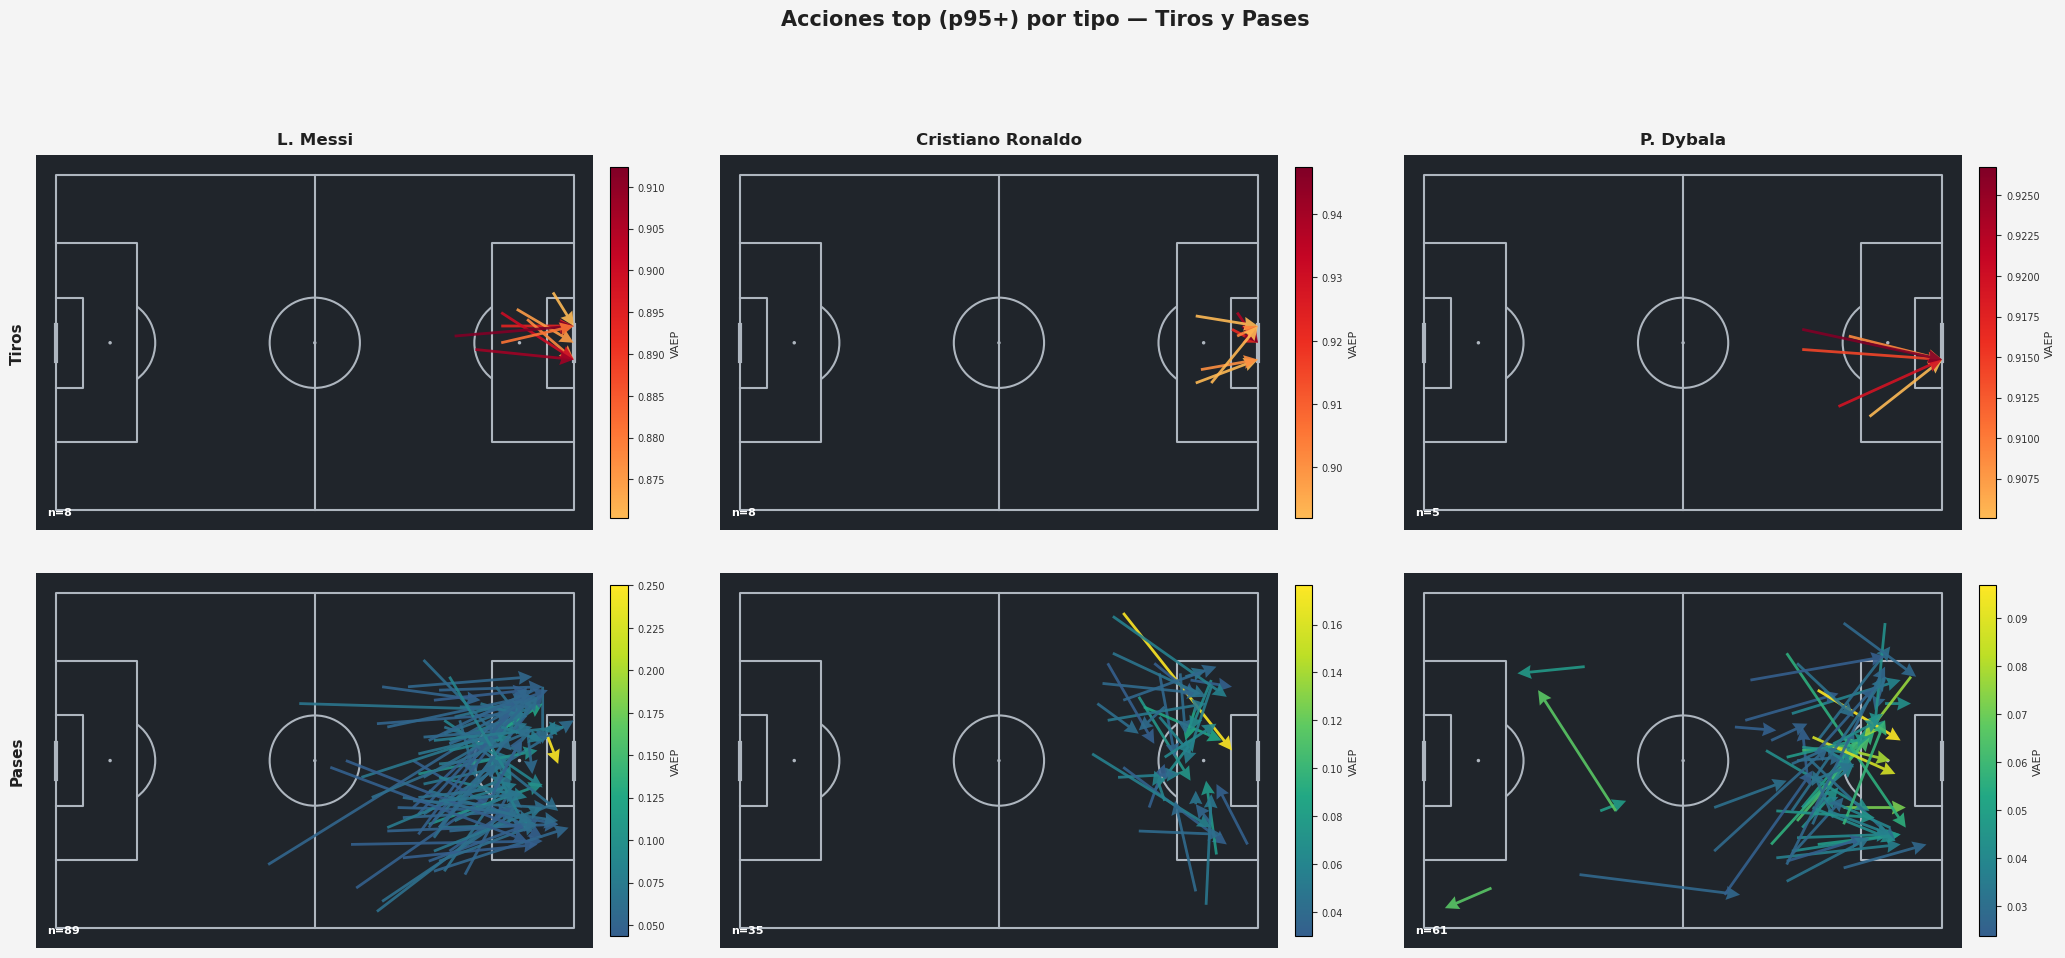

In [44]:
# Flujo de acciones de alto impacto por tipo: shot y pass
# Una fila por tipo de acción, una columna por jugador

tipos = ['shot', 'pass']
etiquetas_tipo = {'shot': 'Tiros', 'pass': 'Pases'}

FIG_BG   = '#f4f4f4'
PITCH_BG = '#20252b'
LINE_COLOR = '#aeb6bf'

cmaps_tipo = {
    'shot': LinearSegmentedColormap.from_list(
        'shot_cmap',
        cm.get_cmap('YlOrRd')([0.35, 0.55, 0.70, 0.85, 1.00])
    ),
    'pass': LinearSegmentedColormap.from_list(
        'pass_cmap',
        cm.get_cmap('viridis')([0.30, 0.45, 0.60, 0.75, 0.90, 1.00])
    )
}

fig, axes = plt.subplots(
    len(tipos), len(jugadores_clave),
    figsize=(21, 10),
    facecolor=FIG_BG
)

for row, tipo in enumerate(tipos):
    for col, (pid, nombre) in enumerate(jugadores_clave.items()):
        ax = axes[row][col]

        df_p = df_vaep[
            (df_vaep['player_id'] == pid) &
            (df_vaep['type_name'] == tipo) &
            df_vaep['end_x'].notna() &
            df_vaep['end_y'].notna()
        ].copy()

        pitch = Pitch(
            pitch_type='custom', pitch_length=105, pitch_width=68,
            pitch_color=PITCH_BG, line_color=LINE_COLOR,
            linewidth=1.5, line_zorder=1
        )
        pitch.draw(ax=ax)

        if len(df_p) > 0:
            # Percentil 95+ dentro del tipo para ese jugador
            umbral = df_p['vaep_value'].quantile(0.95)
            df_top = df_p[df_p['vaep_value'] >= umbral].copy()

            if len(df_top) > 0:
                norm = mcolors.Normalize(
                    vmin=df_top['vaep_value'].min(),
                    vmax=df_top['vaep_value'].max()
                )
                colors = cmaps_tipo[tipo](norm(df_top['vaep_value'].values))

                pitch.arrows(
                    df_top['start_x'], df_top['start_y'],
                    df_top['end_x'],   df_top['end_y'],
                    color=colors, width=2.0, headwidth=5, headlength=5,
                    alpha=0.90, ax=ax, zorder=5
                )

                sm = plt.cm.ScalarMappable(cmap=cmaps_tipo[tipo], norm=norm)
                sm.set_array([])
                cbar = fig.colorbar(sm, ax=ax, shrink=0.72, pad=0.025)
                cbar.set_label('VAEP', fontsize=8, color='#303030')
                cbar.ax.tick_params(labelsize=7, colors='#303030')

            n = len(df_top)
        else:
            n = 0

        # Título solo en la primera fila
        if row == 0:
            ax.set_title(
                nombre,
                color='#202020', fontsize=12, fontweight='bold', pad=8
            )

        # Etiqueta del tipo de acción solo en la primera columna
        if col == 0:
            ax.set_ylabel(
                etiquetas_tipo[tipo],
                color='#202020', fontsize=11, fontweight='bold',
                labelpad=8
            )

        ax.annotate(
            f'n={n}',
            xy=(0.02, 0.04), xycoords='axes fraction',
            color='white', fontsize=8, fontweight='bold'
        )

fig.suptitle(
    'Acciones top (p95+) por tipo — Tiros y Pases',
    color='#202020', fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

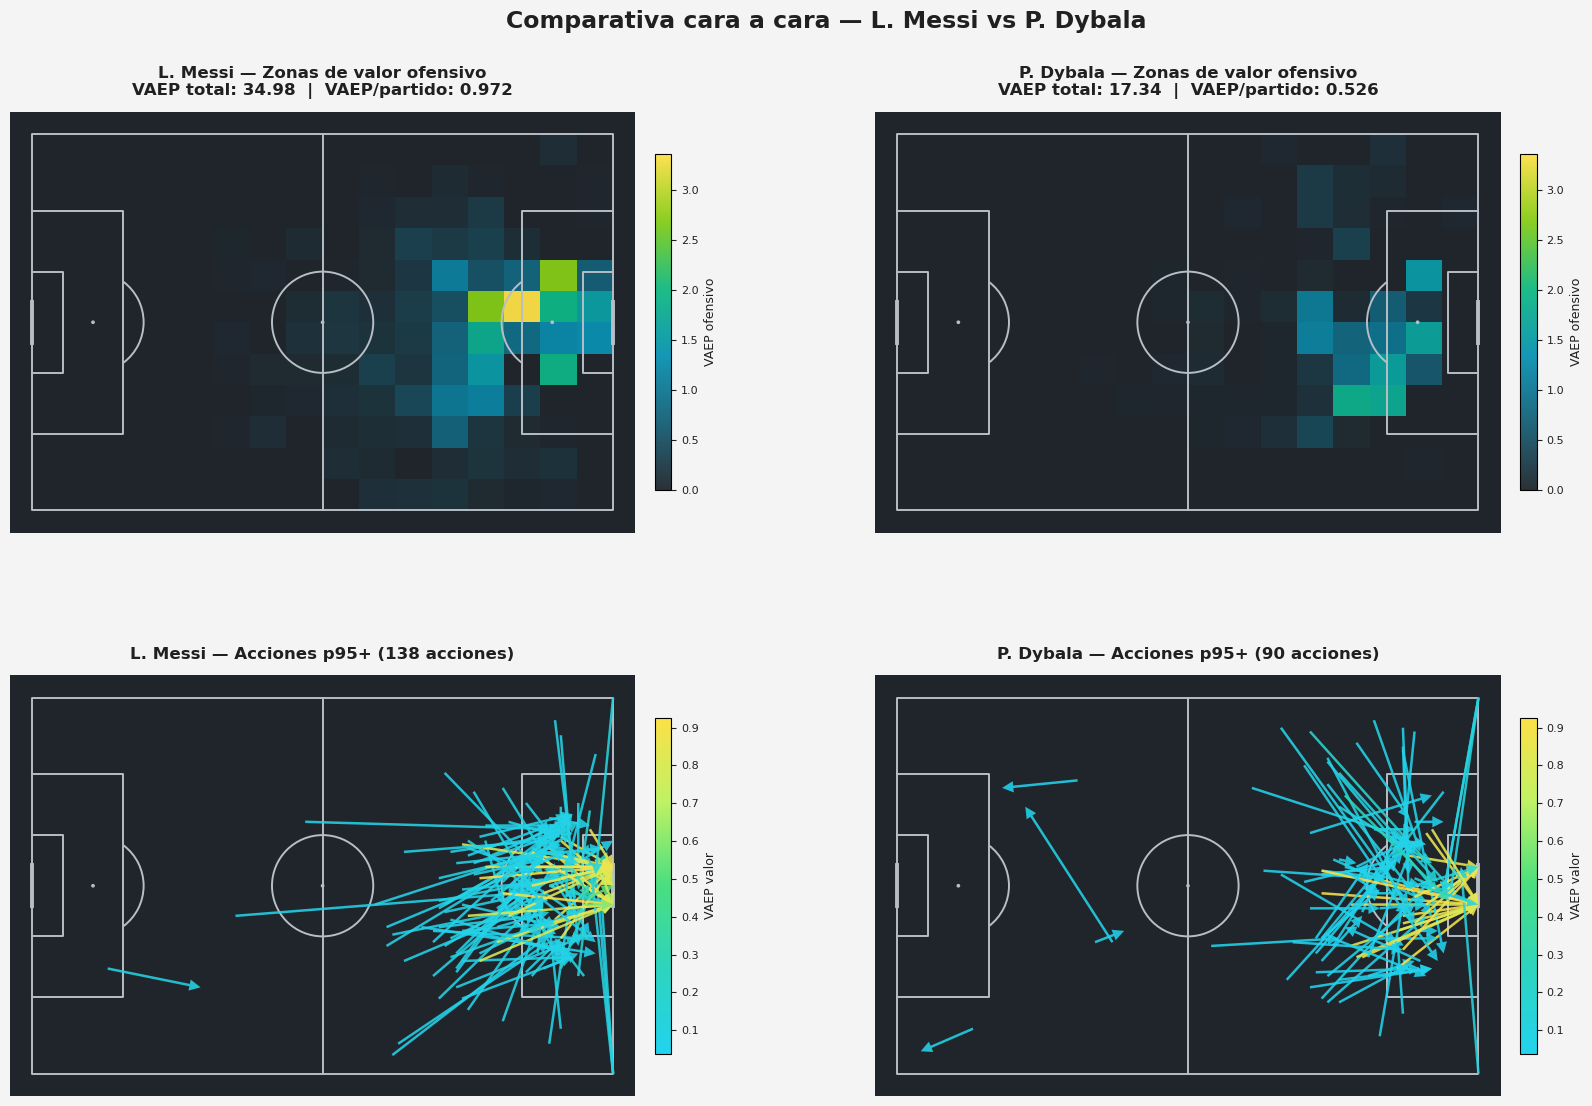

In [45]:
# 3. Comparativa Visual Cara a Cara — Messi vs Dybala 

# Dos paneles por jugador:
# mapa de calor de valor ofensivo + flujo de acciones top (p95+).


# ============================================================
# ESTILO GENERAL
# ============================================================

FIG_BG = '#f4f4f4'
PITCH_BG = '#20252b'
LINE_COLOR = '#b8bec5'
TEXT_COLOR = '#202020'

# Heatmap:
# parte del mismo color de la cancha para que las zonas
# de valor bajo no "pinten" todo el campo.
cmap_heat = LinearSegmentedColormap.from_list(
    'vaep_heat',
    [
        '#20252b',   # fondo / valor muy bajo
        '#155e75',   # azul petróleo
        '#0891b2',   # cyan
        '#10b981',   # verde
        '#84cc16',   # lima
        '#fde047'    # amarillo = máximo valor
    ]
)

# Flechas:
# evitamos colores oscuros para garantizar contraste.
cmap_flow = LinearSegmentedColormap.from_list(
    'vaep_flow',
    [
        '#22d3ee',   # cyan brillante
        '#2dd4bf',   # turquesa
        '#4ade80',   # verde
        '#bef264',   # lima
        '#fde047'    # amarillo
    ]
)

# ============================================================
# DATOS DE LOS DOS JUGADORES
# ============================================================

jugadores_comp = [
    (3359, "L. Messi"),
    (89186, "P. Dybala")
]

datos = {}

for pid, nombre in jugadores_comp:

    df_p = df_vaep[
        df_vaep['player_id'] == pid
    ].copy()

    df_top = df_p[
        df_p['vaep_value'] >=
        df_p['vaep_value'].quantile(0.95)
    ].dropna(subset=['end_x', 'end_y'])

    # Estadística espacial para heatmap
    pitch_temp = Pitch(
        pitch_type='custom',
        pitch_length=105,
        pitch_width=68
    )

    bs = pitch_temp.bin_statistic(
        df_p['start_x'],
        df_p['start_y'],
        values=df_p['off_value'],
        statistic='sum',
        bins=(16, 12)
    )

    datos[pid] = {
        'nombre': nombre,
        'df_p': df_p,
        'df_top': df_top,
        'bs': bs
    }

# ============================================================
# ESCALAS COMUNES
# ============================================================

# ---- Heatmaps ----
heat_values = np.concatenate([
    datos[pid]['bs']['statistic'].ravel()
    for pid, _ in jugadores_comp
])

heat_values = heat_values[
    np.isfinite(heat_values)
]

# Usamos 0 como centro visual.
# Esto también permite distinguir contribuciones negativas.
heat_max = max(
    abs(heat_values.min()),
    abs(heat_values.max())
)

norm_heat = mcolors.Normalize(
    vmin=0,
    vmax=heat_max
)

# ---- Flechas ----
flow_values = np.concatenate([
    datos[pid]['df_top']['vaep_value'].values
    for pid, _ in jugadores_comp
    if len(datos[pid]['df_top']) > 0
])

norm_flow = mcolors.Normalize(
    vmin=flow_values.min(),
    vmax=flow_values.max()
)

# ============================================================
# FIGURA
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12),
    facecolor=FIG_BG
)

# Más espacio vertical para que no se pisen los títulos
fig.subplots_adjust(
    left=0.04,
    right=0.95,
    bottom=0.06,
    top=0.88,
    wspace=0.12,
    hspace=0.34
)

# ============================================================
# GRÁFICOS
# ============================================================

for col, (pid, nombre) in enumerate(jugadores_comp):

    df_p = datos[pid]['df_p']
    df_top = datos[pid]['df_top']
    bs = datos[pid]['bs']

    # --------------------------------------------------------
    # PANEL SUPERIOR — HEATMAP
    # --------------------------------------------------------

    ax_heat = axes[0, col]

    pitch = Pitch(
        pitch_type='custom',
        pitch_length=105,
        pitch_width=68,
        pitch_color=PITCH_BG,
        line_color=LINE_COLOR,
        linewidth=1.4,
        line_zorder=3
    )

    pitch.draw(ax=ax_heat)

    hm = pitch.heatmap(
        bs,
        ax=ax_heat,
        cmap=cmap_heat,
        norm=norm_heat,
        edgecolors='none',
        alpha=0.95,
        zorder=1
    )

    # Colorbar
    cbar_heat = fig.colorbar(
        hm,
        ax=ax_heat,
        shrink=0.80,
        pad=0.025
    )

    cbar_heat.set_label(
        'VAEP ofensivo',
        fontsize=9,
        color=TEXT_COLOR
    )

    cbar_heat.ax.tick_params(
        labelsize=8,
        colors=TEXT_COLOR
    )

    # Métricas
    vaep_total = df_p['vaep_value'].sum()
    n_partidos = max(
        df_p['game_id'].nunique(),
        1
    )
    vaep_partido = vaep_total / n_partidos

    ax_heat.set_title(
        f'{nombre} — Zonas de valor ofensivo\n'
        f'VAEP total: {vaep_total:.2f}  |  '
        f'VAEP/partido: {vaep_partido:.3f}',
        color=TEXT_COLOR,
        fontsize=12,
        fontweight='bold',
        pad=12
    )

    # --------------------------------------------------------
    # PANEL INFERIOR — ACCIONES TOP
    # --------------------------------------------------------

    ax_flow = axes[1, col]

    pitch2 = Pitch(
        pitch_type='custom',
        pitch_length=105,
        pitch_width=68,
        pitch_color=PITCH_BG,
        line_color=LINE_COLOR,
        linewidth=1.4,
        line_zorder=1
    )

    pitch2.draw(ax=ax_flow)

    if len(df_top) > 0:

        colors = cmap_flow(
            norm_flow(
                df_top['vaep_value'].values
            )
        )

        pitch2.arrows(
            df_top['start_x'],
            df_top['start_y'],
            df_top['end_x'],
            df_top['end_y'],
            color=colors,
            width=1.8,
            headwidth=4.5,
            headlength=4.5,
            alpha=0.88,
            ax=ax_flow,
            zorder=5
        )

        sm = plt.cm.ScalarMappable(
            cmap=cmap_flow,
            norm=norm_flow
        )

        sm.set_array([])

        cbar_flow = fig.colorbar(
            sm,
            ax=ax_flow,
            shrink=0.80,
            pad=0.025
        )

        cbar_flow.set_label(
            'VAEP valor',
            fontsize=9,
            color=TEXT_COLOR
        )

        cbar_flow.ax.tick_params(
            labelsize=8,
            colors=TEXT_COLOR
        )

    ax_flow.set_title(
        f'{nombre} — Acciones p95+ '
        f'({len(df_top)} acciones)',
        color=TEXT_COLOR,
        fontsize=12,
        fontweight='bold',
        pad=12
    )

# ============================================================
# TÍTULO GENERAL
# ============================================================

fig.suptitle(
    'Comparativa cara a cara — L. Messi vs P. Dybala',
    color=TEXT_COLOR,
    fontsize=17,
    fontweight='bold',
    y=0.965
)

plt.show()

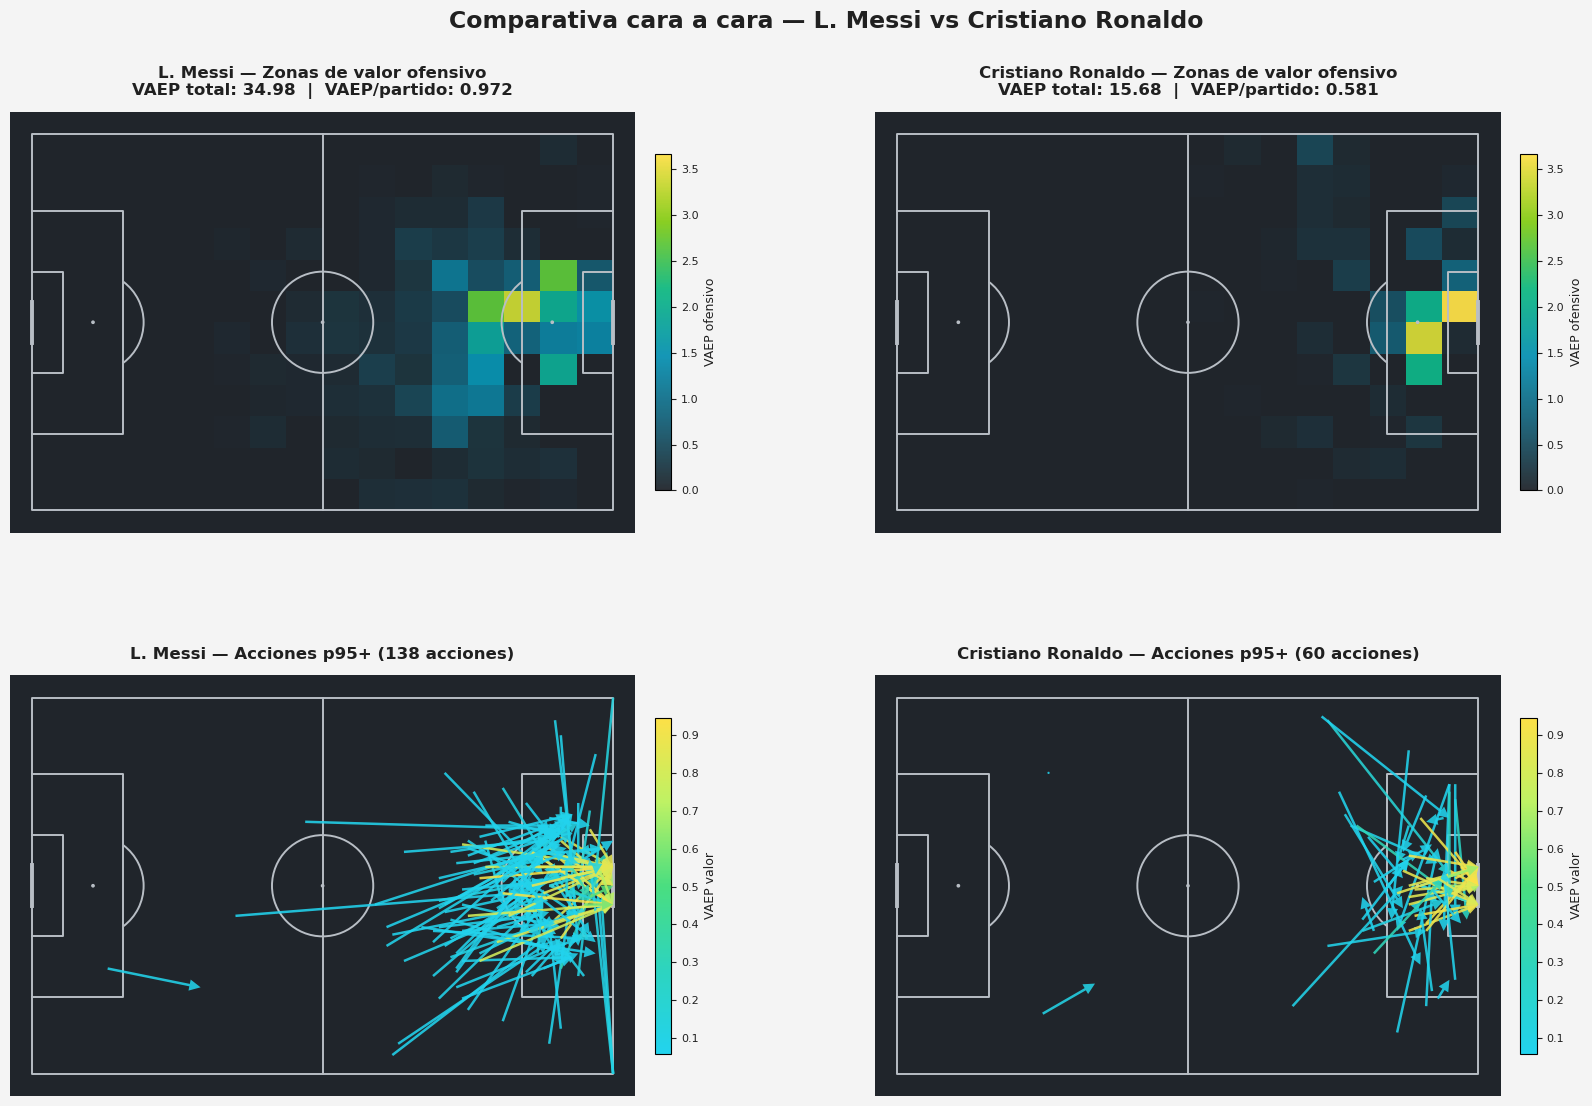

In [46]:
# 3. Comparativa Visual Cara a Cara — Messi vs Cristiano Ronaldo
# Dos paneles por jugador:
# mapa de calor de valor ofensivo + flujo de acciones top (p95+).

# ============================================================
# ESTILO GENERAL
# ============================================================

FIG_BG = '#f4f4f4'
PITCH_BG = '#20252b'
LINE_COLOR = '#b8bec5'
TEXT_COLOR = '#202020'

# Heatmap:
# parte del mismo color de la cancha para que las zonas
# de valor bajo no "pinten" todo el campo.
cmap_heat = LinearSegmentedColormap.from_list(
    'vaep_heat',
    [
        '#20252b',   # fondo / valor muy bajo
        '#155e75',   # azul petróleo
        '#0891b2',   # cyan
        '#10b981',   # verde
        '#84cc16',   # lima
        '#fde047'    # amarillo = máximo valor
    ]
)

# Flechas:
# colores brillantes para garantizar contraste.
cmap_flow = LinearSegmentedColormap.from_list(
    'vaep_flow',
    [
        '#22d3ee',   # cyan brillante
        '#2dd4bf',   # turquesa
        '#4ade80',   # verde
        '#bef264',   # lima
        '#fde047'    # amarillo
    ]
)

# ============================================================
# JUGADORES A COMPARAR
# ============================================================

# Se toman directamente desde jugadores_clave
jugadores_comp = [
    (3359, jugadores_clave[3359]),   # L. Messi
    (3322, jugadores_clave[3322])    # Cristiano Ronaldo
]

datos = {}

# ============================================================
# PREPARACIÓN DE DATOS
# ============================================================

for pid, nombre in jugadores_comp:

    df_p = df_vaep[
        df_vaep['player_id'] == pid
    ].copy()

    # Acciones en percentil 95+
    df_top = df_p[
        df_p['vaep_value'] >=
        df_p['vaep_value'].quantile(0.95)
    ].dropna(subset=['end_x', 'end_y'])

    # Estadística espacial para heatmap
    pitch_temp = Pitch(
        pitch_type='custom',
        pitch_length=105,
        pitch_width=68
    )

    bs = pitch_temp.bin_statistic(
        df_p['start_x'],
        df_p['start_y'],
        values=df_p['off_value'],
        statistic='sum',
        bins=(16, 12)
    )

    datos[pid] = {
        'nombre': nombre,
        'df_p': df_p,
        'df_top': df_top,
        'bs': bs
    }

# ============================================================
# ESCALAS COMUNES
# Esto permite comparar visualmente Messi vs Cristiano
# ============================================================

# ---------- HEATMAP ----------

heat_values = np.concatenate([
    datos[pid]['bs']['statistic'].ravel()
    for pid, _ in jugadores_comp
])

heat_values = heat_values[
    np.isfinite(heat_values)
]

# Escala común para ambos jugadores
heat_max = max(
    0,
    heat_values.max()
)

norm_heat = mcolors.Normalize(
    vmin=0,
    vmax=heat_max
)

# ---------- FLECHAS ----------

flow_values = np.concatenate([
    datos[pid]['df_top']['vaep_value'].values
    for pid, _ in jugadores_comp
    if len(datos[pid]['df_top']) > 0
])

# Misma escala VAEP para Messi y Cristiano
norm_flow = mcolors.Normalize(
    vmin=flow_values.min(),
    vmax=flow_values.max()
)

# ============================================================
# FIGURA
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12),
    facecolor=FIG_BG
)

# Espaciado manual para evitar títulos superpuestos
fig.subplots_adjust(
    left=0.04,
    right=0.95,
    bottom=0.06,
    top=0.88,
    wspace=0.12,
    hspace=0.34
)

# ============================================================
# GRÁFICOS
# ============================================================

for col, (pid, nombre) in enumerate(jugadores_comp):

    df_p = datos[pid]['df_p']
    df_top = datos[pid]['df_top']
    bs = datos[pid]['bs']

    # ========================================================
    # PANEL SUPERIOR — MAPA DE CALOR
    # ========================================================

    ax_heat = axes[0, col]

    pitch = Pitch(
        pitch_type='custom',
        pitch_length=105,
        pitch_width=68,
        pitch_color=PITCH_BG,
        line_color=LINE_COLOR,
        linewidth=1.4,
        line_zorder=3
    )

    pitch.draw(ax=ax_heat)

    hm = pitch.heatmap(
        bs,
        ax=ax_heat,
        cmap=cmap_heat,
        norm=norm_heat,
        edgecolors='none',
        alpha=0.95,
        zorder=1
    )

    # Barra de color
    cbar_heat = fig.colorbar(
        hm,
        ax=ax_heat,
        shrink=0.80,
        pad=0.025
    )

    cbar_heat.set_label(
        'VAEP ofensivo',
        fontsize=9,
        color=TEXT_COLOR
    )

    cbar_heat.ax.tick_params(
        labelsize=8,
        colors=TEXT_COLOR
    )

    # Métricas
    vaep_total = df_p['vaep_value'].sum()

    n_partidos = max(
        df_p['game_id'].nunique(),
        1
    )

    vaep_partido = vaep_total / n_partidos

    ax_heat.set_title(
        f'{nombre} — Zonas de valor ofensivo\n'
        f'VAEP total: {vaep_total:.2f}  |  '
        f'VAEP/partido: {vaep_partido:.3f}',
        color=TEXT_COLOR,
        fontsize=12,
        fontweight='bold',
        pad=12
    )

    # ========================================================
    # PANEL INFERIOR — FLUJO DE ACCIONES TOP
    # ========================================================

    ax_flow = axes[1, col]

    pitch2 = Pitch(
        pitch_type='custom',
        pitch_length=105,
        pitch_width=68,
        pitch_color=PITCH_BG,
        line_color=LINE_COLOR,
        linewidth=1.4,
        line_zorder=1
    )

    pitch2.draw(ax=ax_flow)

    if len(df_top) > 0:

        colors = cmap_flow(
            norm_flow(
                df_top['vaep_value'].values
            )
        )

        pitch2.arrows(
            df_top['start_x'],
            df_top['start_y'],
            df_top['end_x'],
            df_top['end_y'],
            color=colors,
            width=1.8,
            headwidth=4.5,
            headlength=4.5,
            alpha=0.88,
            ax=ax_flow,
            zorder=5
        )

        # Barra de color
        sm = plt.cm.ScalarMappable(
            cmap=cmap_flow,
            norm=norm_flow
        )

        sm.set_array([])

        cbar_flow = fig.colorbar(
            sm,
            ax=ax_flow,
            shrink=0.80,
            pad=0.025
        )

        cbar_flow.set_label(
            'VAEP valor',
            fontsize=9,
            color=TEXT_COLOR
        )

        cbar_flow.ax.tick_params(
            labelsize=8,
            colors=TEXT_COLOR
        )

    ax_flow.set_title(
        f'{nombre} — Acciones p95+ '
        f'({len(df_top)} acciones)',
        color=TEXT_COLOR,
        fontsize=12,
        fontweight='bold',
        pad=12
    )

# ============================================================
# TÍTULO GENERAL
# ============================================================

fig.suptitle(
    'Comparativa cara a cara — L. Messi vs Cristiano Ronaldo',
    color=TEXT_COLOR,
    fontsize=17,
    fontweight='bold',
    y=0.965
)

plt.show()

#### Conclusiones Ejercicio 3

El modelo VAEP permite valorar acciones de acuerdo a su contribución a la probabilidad de derivar en gol propio (suma para VAEP) o conceder un gol (resta VAEP). Al poder calcularse por acción, podemos asociar cada una a jugadores y a las posiciones de dichas acciones. Por ello es una buena estrategia poder mapear las acciones que mayor VAEP generan, con las cuadrículas en la cancha para generar un mapa de calor por jugador para ver dónde es más determinante cada jugador. En nuestro ejemplo, realizamos los mapas de calor para Messi, Cristiano Ronaldo y Paulo Dybala, para poder analizar diferentes patrones. 

Messi es el jugador con mayor VAEP por partido de todo el dataset, y de manera consistente con lo observado a través de los años, Messi, siendo zurdo, genera más acciones peligrosas en el borde del área, explicado por remates desde afuera, tiros libres y por supuesto, remates desde adentro del área también. En cambio, Cristiano genera mayor peligro casi exclusivamente dentro del área, del centro hacia la derecha. Un matiz entre ambos jugadores es que dentro de las acciones con mayor valoración, en el caso de Messi predominan los pases (en cantidad, no en peligro), mientras que para Cristiano predominan los remates al arco. Además, Messi tiene casi la misma cantidad de remates (26) que regates (take_on), con 23 casos, lo cuál marca una diferencia conceptual grande: Messi no necesita rematar constantemente para generar peligro, sino que puede hacerlo mediante pases, regates y remates, mientras que Cristiano casi exclusivamente genera peligro a partir de los remates. De manera consistente con ello, los tiros de Cristiano, en promedio, generan más VAEP que los de Messi (0.8571 VAEP promedio, contra 0.8240 de Messi). Por su parte, Dybala presenta un perfil más parecido a Messi, con fuerte participación de pases, pelotas paradas, por eso su mapa de calor muestra concentración fuera del área, y con acciones quizás menos determinantes que Lionel y Cristiano. 

Con la ayuda del flujo de acciones de alto impacto con la posibilidad de generar fechas con el inicio y fin de jugadas, se observa la gran cantidad de acciones de Messi, con VAEP relativamente bajo, pero con fuerte distribución desde la derecha y afuera del área hacia dentro del área y el arco. En el caso de Cristiano, que tiene menos de la mitad de acciones top que Messi, se observa mayor densidad de flechas dentro del área, y pocas comienzan fuera, que coincide con su perfil de delantero de área, en contraposición de Messi que participa más del juego, al igual que Dybala. En el caso de Dybala se observa mucha presencia fuera del área, explicada en parte por su carácter de constructor de juego, pero también responsable de la pelota parada, ya que a diferencia de Messi, se observan muchas flechas que no terminan directamente en el arco. Si es relevante mencionar también, que Messi y Dybala complementan su valor agregado con una importante presencia de tiros libres al arco, que en el caso de ambos, generan en promedio un peligro similar). 

En la comparación mano a mano entre Messi y Dybala, que como se mencionó antes presentan perfiles similares, con gran participación de acciones con mayor VAEP fuera del área, se observa una mayor densidad de acciones, reflejada en la cantidad de flechas, por parte de Lionel. En el caso de Messi, se observa claramente que comienza a generar peligro desde la derecha, trazando muchas diagonales. Paulo, que ocupa tácticamente una posición similar, también tiene fuerte presencia del lado derecho, pero también se observan muchas flechas largas correspondientes a acciones de pelota parada. 

En cambio, en la comparación entre Messi y Cristiano se resalta la gran densidad de flechas, y si bien son de baja peligrosidad en general, terminan contribuyendo a la saturación del mapa de calor observado, mientras que Cristiano presenta menos acciones.



### Ejercicio 4 — Clustering por liga
Aplicá el pipeline de clustering a todas las ligas disponibles.
¿Los mismos perfiles aparecen en todas las ligas? ¿Hay perfiles de juego únicos
de alguna liga en particular?

In [47]:
# ============================================================
# Ejercicio 4 — Clustering por liga
# 1) Asignamos cada partido y cada jugador a su liga de origen.
# ============================================================


def build_game_league_map(leagues=('England', 'Italy', 'Spain')):
    # Construye el mapeo game_id -> liga leyendo los JSON de Wyscout
    base = None
    for cand in [
        Path('../data/matches'),
        Path('data/matches'),
        Path('../../data/matches'),
    ]:
        if cand.exists():
            base = cand
            break
    if base is None:
        raise FileNotFoundError('No se encontró el directorio data/matches')

    frames = []
    for league in leagues:
        fp = base / f'matches_{league}.json'
        if not fp.exists():
            print(f'  ! Falta {fp.name}, se omite')
            continue
        matches = pd.read_json(fp)
        frames.append(
            pd.DataFrame({'game_id': matches['wyId'].astype(int), 'league': league})
        )
    return pd.concat(frames, ignore_index=True)


if 'league' not in df_vaep.columns:
    df_vaep = df_vaep.merge(build_game_league_map(), on='game_id', how='left')

print('Acciones por liga:')
print(df_vaep['league'].value_counts(dropna=False))

# Liga de cada jugador = liga donde disputó más acciones
player_league = (
    df_vaep.dropna(subset=['league'])
    .groupby('player_id')['league']
    .agg(lambda s: s.value_counts().index[0])
)

n_multi = (
    df_vaep.dropna(subset=['league'])
    .groupby('player_id')['league']
    .nunique()
    .gt(1)
    .sum()
)
print(f'\nJugadores con liga asignada: {len(player_league)}')
print(f'Jugadores con acciones en más de una liga: {n_multi}')

# Adjuntamos la liga a los vectores de jugador del pipeline global
pv = player_vectors.copy()
pv['league'] = pv.index.map(player_league)
pv = pv.dropna(subset=['league']).copy()
# Excluimos player_id 0 (jugador 'desconocido' de Wyscout): es un artefacto
pv = pv[pv.index > 0].copy()
print(f'Jugadores del clustering con liga conocida: {len(pv)}')

Acciones por liga:
league
Italy      496015
England    483597
Spain      474866
Name: count, dtype: int64

Jugadores con liga asignada: 1582
Jugadores con acciones en más de una liga: 22
Jugadores del clustering con liga conocida: 1200


Cantidad de jugadores por liga y cluster global:
cluster    0    1   2   3
league                   
England  108  201  27  48
Italy    105  220  25  55
Spain    109  208  27  67

Proporción de cada cluster dentro de cada liga:
cluster      0      1      2      3
league                             
England  0.281  0.523  0.070  0.125
Italy    0.259  0.543  0.062  0.136
Spain    0.265  0.506  0.066  0.163


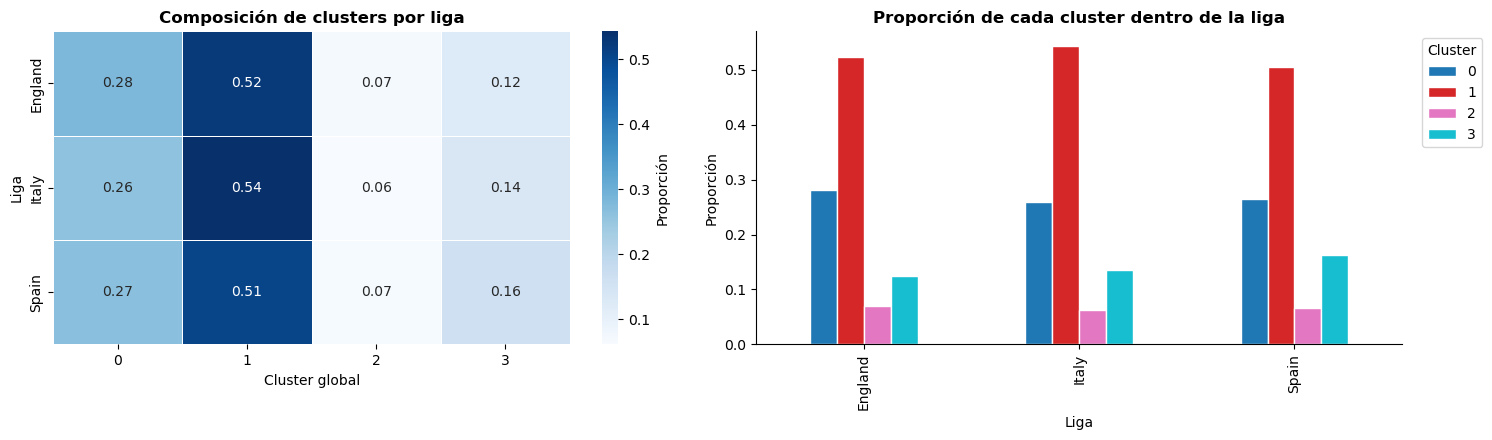

In [48]:
# ============================================================
# 2) ¿Los clusters globales se reparten igual entre ligas?
# ============================================================

tabla_liga_cluster = pd.crosstab(pv['league'], pv['cluster'])
prop_liga_cluster = pd.crosstab(pv['league'], pv['cluster'], normalize='index')

print('Cantidad de jugadores por liga y cluster global:')
print(tabla_liga_cluster.to_string())

print('\nProporción de cada cluster dentro de cada liga:')
print(prop_liga_cluster.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

sns.heatmap(
    prop_liga_cluster,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Proporción'},
    ax=axes[0],
)
axes[0].set_title('Composición de clusters por liga', fontweight='bold')
axes[0].set_xlabel('Cluster global')
axes[0].set_ylabel('Liga')

prop_liga_cluster.plot(
    kind='bar', ax=axes[1], colormap='tab10', edgecolor='white'
)
axes[1].set_title('Proporción de cada cluster dentro de la liga', fontweight='bold')
axes[1].set_xlabel('Liga')
axes[1].set_ylabel('Proporción')
axes[1].legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

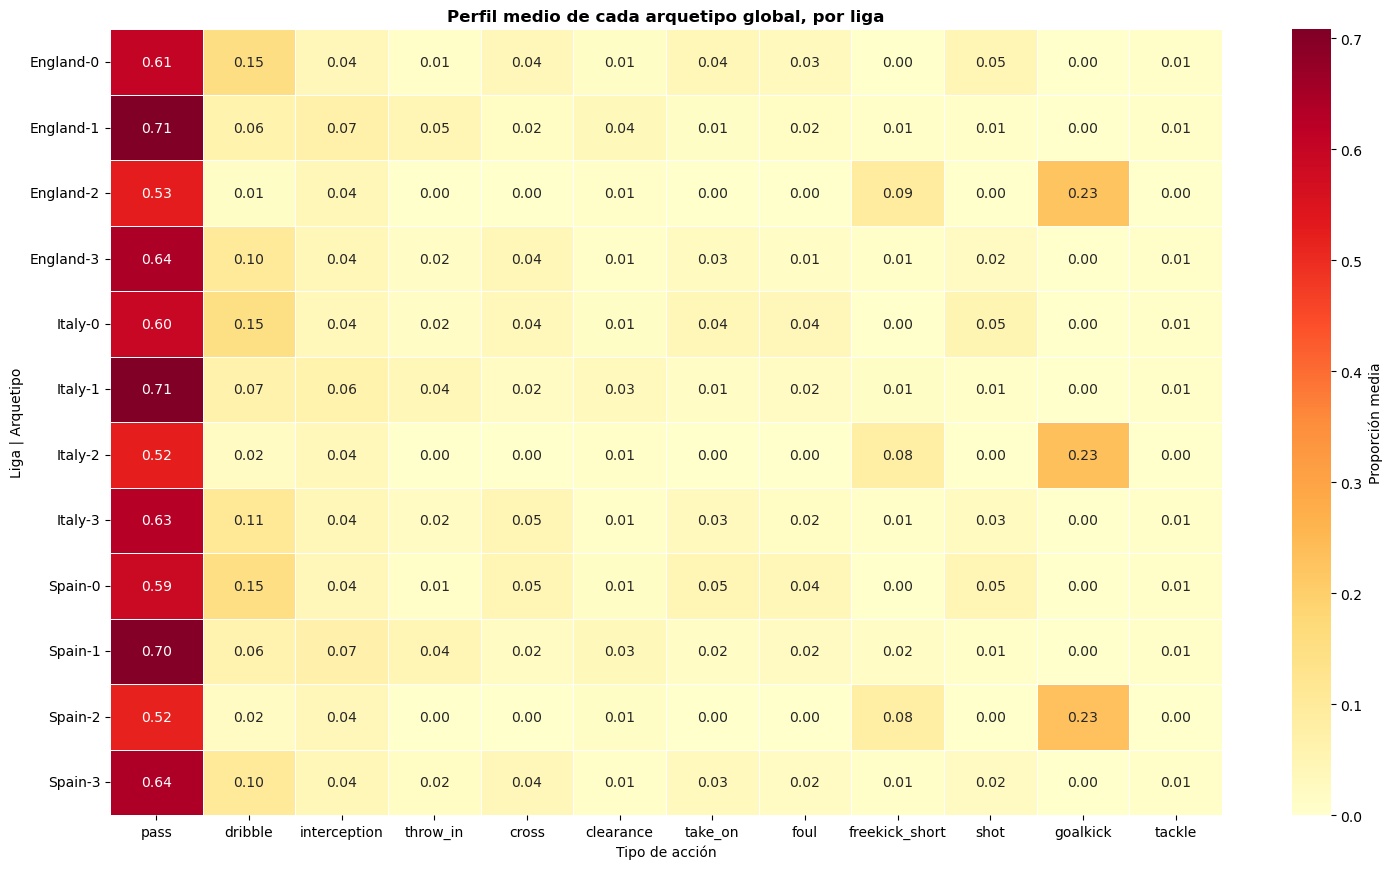

Consistencia de cada arquetipo entre ligas (0 = perfil idéntico):
 cluster  n_jugadores  dist_media  dist_max
       0          322      0.0175    0.0222
       3          170      0.0152    0.0178
       2           79      0.0150    0.0188
       1          629      0.0119    0.0122


In [49]:
# ============================================================
# 3) Usamos los clusters GLOBALES como taxonomía común de
#    arquetipos y medimos si cada perfil se repite entre ligas.
# ============================================================
from sklearn.metrics.pairwise import euclidean_distances

feature_cols = [c for c in player_vectors.columns if c != 'cluster']
action_cols = [
    c for c in feature_cols
    if c not in ['vaep_p90', 'off_total', 'def_total']
]

X_scaled = pd.DataFrame(
    X_cluster, index=player_vectors.index, columns=feature_cols
)

# Perfil medio (proporción de cada tipo de acción) por liga y arquetipo
perfil_liga_cluster = pv.groupby(['league', 'cluster'])[action_cols].mean()

top_actions = df_vaep['type_name'].value_counts().head(12).index.tolist()
top_actions = [a for a in top_actions if a in action_cols]

plt.figure(
    figsize=(2 + 1.1 * len(top_actions), 1.6 + 0.6 * len(perfil_liga_cluster))
)
sns.heatmap(
    perfil_liga_cluster[top_actions],
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Proporción media'},
)
plt.title('Perfil medio de cada arquetipo global, por liga', fontweight='bold')
plt.xlabel('Tipo de acción')
plt.ylabel('Liga | Arquetipo')
plt.tight_layout()
plt.show()

# Consistencia de cada arquetipo entre ligas (distancia euclídea)
resumen = []
for c in sorted(pv['cluster'].unique()):
    sub = perfil_liga_cluster.xs(c, level='cluster')
    if len(sub) < 2:
        continue
    D = euclidean_distances(sub.values)
    iu = np.triu_indices_from(D, k=1)
    resumen.append(
        {
            'cluster': int(c),
            'n_jugadores': int((pv['cluster'] == c).sum()),
            'dist_media': D[iu].mean(),
            'dist_max': D.max(),
        }
    )
consistencia = pd.DataFrame(resumen).sort_values('dist_media', ascending=False)
print('Consistencia de cada arquetipo entre ligas (0 = perfil idéntico):')
print(consistencia.round(4).to_string(index=False))

In [50]:
# ============================================================
# 4) ¿Hay jugadores/perfiles que no encajen en la taxonomía global?
#    Candidatos a perfil propio de una liga.
# ============================================================

# Centroide global de cada arquetipo en el espacio estandarizado
centro_global = X_scaled.groupby(player_vectors['cluster']).mean()

# Distancia de cada jugador al centroide de su arquetipo
distancias = np.linalg.norm(
    X_scaled.loc[pv.index].values - centro_global.loc[pv['cluster']].values,
    axis=1,
)
pv_dist = pv.assign(dist_arquetipo=distancias)

resumen_liga = (
    pv_dist.groupby('league')['dist_arquetipo']
    .agg(
        n='size',
        mediana='median',
        p90=lambda s: s.quantile(0.90),
        p99=lambda s: s.quantile(0.99),
        maximo='max',
    )
    .round(3)
)
print('Distancia de cada jugador al centroide de su arquetipo, por liga:')
print(resumen_liga.to_string())

umbral = pv_dist['dist_arquetipo'].quantile(0.95)
candidatos = pv_dist[pv_dist['dist_arquetipo'] >= umbral]
print(f'\nJugadores en el 5% con mayor distancia (>= {umbral:.2f}):')
print(candidatos.groupby('league').size().sort_values(ascending=False).to_string())

print('\nEjemplos de perfiles atípicos:')
ejemplos = candidatos.sort_values('dist_arquetipo', ascending=False).copy()
ejemplos['jugador'] = [player_names.get(pid, str(pid)) for pid in ejemplos.index]
print(ejemplos[['league', 'dist_arquetipo', 'jugador']].head(10).to_string(index=False))

Distancia de cada jugador al centroide de su arquetipo, por liga:
           n  mediana    p90    p99  maximo
league                                     
England  384    2.941  4.316  6.712   8.504
Italy    405    2.726  4.360  8.506  10.762
Spain    411    2.949  4.691  7.990  13.357

Jugadores en el 5% con mayor distancia (>= 5.31):
league
Italy      22
Spain      22
England    16

Ejemplos de perfiles atípicos:
 league  dist_arquetipo           jugador
  Spain       13.357331          L. Messi
  Italy       10.761716        G. Pazzini
  Italy       10.230466         M. Icardi
  Italy        9.395392       G. Lapadula
  Italy        9.290923          A. Matri
  Spain        9.042612       Samu García
  Spain        9.034329 Cristiano Ronaldo
  Spain        8.733834        Pedro León
  Italy        8.535546        S. Calvano
England        8.503798           H. Kane


#### Conclusiones del Ejercicio 4

**Metodología.** Para comparar ligas usamos los **clusters globales** (sección 5) como una taxonomía común de arquetipos, en lugar de re-entrenar K-Means por liga. Así evitamos que las etiquetas de los clusters sean arbitrarias en cada corrida y que alguna liga se parta en grupos de 1-2 jugadores. El análisis se hizo sobre 1.200 jugadores con liga conocida (England 384, Italy 405, Spain 411) y se excluyó el `player_id 0` (jugador *desconocido* de Wyscout), que aparecía como un outlier artificial.

**¿Los mismos perfiles aparecen en todas las ligas?** Sí. La composición de arquetipos es prácticamente idéntica en las tres ligas:

| Liga | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 |
| :--- | :---: | :---: | :---: | :---: |
| England | 0.281 | 0.523 | 0.070 | 0.125 |
| Italy | 0.259 | 0.543 | 0.062 | 0.136 |
| Spain | 0.265 | 0.506 | 0.066 | 0.163 |

Y el perfil medio de cada arquetipo apenas cambia entre ligas (distancia euclídea entre los perfiles de las tres ligas):

| Cluster | Jugadores | dist_media | dist_max |
| :---: | :---: | :---: | :---: |
| 0 | 322 | 0.0175 | 0.0222 |
| 1 | 629 | 0.0119 | 0.0122 |
| 2 | 79 | 0.0150 | 0.0188 |
| 3 | 170 | 0.0152 | 0.0178 |

Con proporciones de acción que van de 0 a 1, distancias de 0.012-0.022 indican que el mismo arquetipo se reproduce casi igual en las tres ligas.

**¿Hay perfiles de juego únicos de alguna liga?** No se observa un perfil propio de liga. La distancia de cada jugador al centroide de su arquetipo es similar en las tres ligas (mediana ≈ 2.7-2.9 y p90 ≈ 4.3-4.7), y el 5% más alejado se reparte de forma pareja (Italy 22, Spain 22, England 16). Los casos más atípicos son jugadores individuales, en su mayoría delanteros de área o extremos de élite: L. Messi (13.36), G. Pazzini (10.76), M. Icardi (10.23), G. Lapadula (9.40), A. Matri (9.29), Samu García (9.04), Cristiano Ronaldo (9.03), Pedro León (8.73), S. Calvano (8.54) y H. Kane (8.50).

Es decir, lo que no encaja en la taxonomía global son **estilos individuales muy marcados**, no un estilo de liga. El único matiz anecdótico es que Italia aporta varios delanteros centro clásicos (Pazzini, Icardi, Lapadula, Matri) entre los más atípicos, pero son casos individuales y no un arquetipo exclusivo de la Serie A.

**Conclusión.** Con la resolución de features usada (proporciones de tipos de acción + métricas VAEP), los perfiles de juego son transversales a Inglaterra, Italia y España: las diferencias relevantes aparecen a nivel de jugador (delanteros de élite), no de liga.

### Ejercicio 5 — Sistema de scouting
Construí un sistema de scouting que dado un jugador 'objetivo' (player_id):
1. Muestre su perfil en radar (métricas normalizadas por posición)
2. Identifique sus 5 jugadores más similares
3. Compare VAEP y xT del objetivo vs. similares
4. Indique si hay jugadores similares con mayor VAEP (posibles mejoras de mercado)

Aplicalo para encontrar reemplazante de algún jugador histórico de la temporada.

---
**Entregable**: Notebook completo con pipeline VAEP/xT + análisis de clustering + sistema de scouting documentado.

In [51]:
# ============================================================
# Ejercicio 5 — Sistema de scouting
# 1) Posición y edad de cada jugador (players.json de Wyscout)
#    El notebook no tiene posición: la necesitamos para
#    normalizar el radar "por posición".
# ============================================================

from pathlib import Path


def load_player_meta():
    base = None
    for cand in [Path('../data'), Path('data'), Path('../../data')]:
        if (cand / 'players.json').exists():
            base = cand
            break
    if base is None:
        raise FileNotFoundError('No se encontró data/players.json')

    raw = pd.read_json(base / 'players.json')
    meta = pd.DataFrame({
        'player_id': raw['wyId'].astype(int),
        'posicion': raw['role'].apply(
            lambda r: r.get('code2') if isinstance(r, dict) else None
        ),
        'birth_date': pd.to_datetime(raw['birthDate'], errors='coerce'),
    })
    # Edad al cierre de la temporada 2017/18
    meta['edad'] = (
        (pd.Timestamp('2018-06-30') - meta['birth_date']).dt.days / 365.25
    ).round(1)
    return meta.drop(columns='birth_date')


player_meta = load_player_meta()
POS_NOMBRE = {'GK': 'Arquero', 'DF': 'Defensor', 'MD': 'Mediocampista', 'FW': 'Delantero'}

print('Jugadores con metadata:', len(player_meta))
print(player_meta['posicion'].value_counts().to_string())

Jugadores con metadata: 3603
posicion
MD    1257
DF    1200
FW     720
GK     426


In [52]:
# ============================================================
# 2) Métricas por partido y percentil dentro de la posición
#    Nota: el notebook no tiene minutos jugados, así que
#    "p90" en todo el práctico es en realidad "por partido".
#    Mantenemos ese criterio para ser consistentes.
# ============================================================

TIPOS_METRICA = {
    'pases_pg':      ['pass'],
    'centros_pg':    ['cross'],
    'regates_pg':    ['take_on'],
    'tiros_pg':      ['shot', 'shot_penalty', 'shot_freekick'],
    'defensivas_pg': ['tackle', 'interception', 'clearance'],
}

# Conteo de acciones por jugador y tipo
conteo = df_vaep.groupby(['player_id', 'type_name']).size().unstack(fill_value=0)

scout_base = vaep_by_player.set_index('player_id')[
    ['jugador', 'games', 'vaep_p90', 'off_total', 'def_total']
].copy()
scout_base['off_p90'] = scout_base['off_total'] / scout_base['games']
scout_base['def_p90'] = scout_base['def_total'] / scout_base['games']

# xT por partido (jugadores sin acciones de movimiento quedan en 0)
scout_base = scout_base.join(
    xt_by_player.set_index('player_id')['xT_p90'], how='left'
).fillna({'xT_p90': 0})

for col, tipos in TIPOS_METRICA.items():
    tipos_ok = [t for t in tipos if t in conteo.columns]
    scout_base[col] = (
        conteo[tipos_ok].sum(axis=1).reindex(scout_base.index).fillna(0)
        / scout_base['games']
    )

# Posición, edad y cluster global
scout_base = scout_base.join(player_meta.set_index('player_id'), how='left')
scout_base = scout_base.join(player_vectors[['cluster']], how='inner')
scout_base = scout_base[scout_base.index > 0]           # player_id 0 = desconocido
scout_base = scout_base.dropna(subset=['posicion'])

METRICAS_RADAR = {
    'vaep_p90':      'VAEP',
    'off_p90':       'VAEP ofensivo',
    'def_p90':       'VAEP defensivo',
    'xT_p90':        'xT',
    'pases_pg':      'Pases',
    'centros_pg':    'Centros',
    'regates_pg':    'Regates',
    'tiros_pg':      'Tiros',
    'defensivas_pg': 'Acc. defensivas',
}

# Percentil (0-100) de cada métrica dentro de la misma posición
for col in METRICAS_RADAR:
    scout_base[f'pct_{col}'] = (
        scout_base.groupby('posicion')[col].rank(pct=True) * 100
    ).round(1)

print(f'Jugadores en la base de scouting: {len(scout_base)}')
print(scout_base['posicion'].map(POS_NOMBRE).value_counts().to_string())
print()
print(scout_base[['jugador', 'posicion', 'edad', 'games', 'vaep_p90', 'xT_p90']]
      .sort_values('vaep_p90', ascending=False).head(8).to_string())

Jugadores en la base de scouting: 1200
posicion
Mediocampista    443
Defensor         412
Delantero        266
Arquero           79

                     jugador posicion  edad  games  vaep_p90    xT_p90
player_id                                                             
3359                L. Messi       FW  31.0     36  0.971665  0.738358
120353         Mohamed Salah       FW  26.0     36  0.743972  0.244878
3322       Cristiano Ronaldo       FW  33.4     27  0.580633  0.197468
3802       Philippe Coutinho       FW  26.0     32  0.571269  0.548591
3840              Iago Aspas       FW  30.9     34  0.560428  0.241027
3682            A. Griezmann       FW  27.3     32  0.554639  0.221580
8325               S. Agüero       FW  30.1     25  0.548945  0.098161
8717                 H. Kane       FW  24.9     37  0.529034  0.214640


In [53]:
# ============================================================
# 3) Similitud por estilo
#    Usamos solo las proporciones de tipo de acción (sin VAEP),
#    así la similitud mide cómo juega y el valor se compara aparte.
# ============================================================

COLS_ESTILO = [
    c for c in player_vectors.columns
    if c not in ['cluster', 'vaep_p90', 'off_total', 'def_total']
]
X_estilo = StandardScaler().fit_transform(player_vectors[COLS_ESTILO])


def similares_por_estilo(player_id, top_n=5, misma_posicion=True, min_games=10):
    if player_id not in scout_base.index:
        raise ValueError(f'Jugador {player_id} no está en la base de scouting')

    sim = find_similar_players(
        player_id, X_estilo, player_vectors.index, top_n=len(player_vectors)
    ).set_index('player_id')[['similarity']]
    sim = sim.join(scout_base, how='inner')

    if misma_posicion:
        sim = sim[sim['posicion'] == scout_base.loc[player_id, 'posicion']]
    sim = sim[sim['games'] >= min_games]

    sim = sim.sort_values('similarity', ascending=False).head(top_n)
    sim['rank'] = range(1, len(sim) + 1)
    return sim


# Chequeo rápido con y sin filtro de posición
_pid = int(vaep_by_player.sort_values('vaep_p90', ascending=False).iloc[0]['player_id'])
print(f"Similares de {player_names.get(_pid, _pid)} (misma posición):")
print(similares_por_estilo(_pid)[['rank', 'jugador', 'posicion', 'similarity', 'vaep_p90']]
      .to_string(index=False))
print(f"\nSimilares de {player_names.get(_pid, _pid)} (sin filtro de posición):")
print(similares_por_estilo(_pid, misma_posicion=False)[['rank', 'jugador', 'posicion', 'similarity', 'vaep_p90']]
      .to_string(index=False))

Similares de L. Messi (misma posición):
 rank      jugador posicion  similarity  vaep_p90
    1 A. Ciciretti       FW    0.886819  0.175732
    2   A. Sánchez       FW    0.871791  0.308455
    3    L. Suárez       FW    0.858450  0.484851
    4    A. Ljajić       FW    0.847218  0.440763
    5     S. Verdi       FW    0.842675  0.282454

Similares de L. Messi (sin filtro de posición):
 rank        jugador posicion  similarity  vaep_p90
    1      E. Bardhi       MD    0.904083  0.412306
    2 Renato Sanches       MD    0.895927  0.065820
    3   A. Ciciretti       FW    0.886819  0.175732
    4     João Pedro       MD    0.883635  0.190486
    5     A. Sánchez       FW    0.871791  0.308455


In [54]:
# ============================================================
# 4) Reporte de scouting: radar + similares + VAEP/xT + mejora de mercado
# ============================================================
from mplsoccer import Radar

# Estilo consistente con el Ejercicio 3
FIG_BG     = '#f4f4f4'
PANEL_BG   = '#20252b'
TEXT_COLOR = '#202020'
C_OBJETIVO = '#fde047'   # amarillo
C_SIMILAR  = '#0891b2'   # cyan
C_MEJORA   = '#10b981'   # verde
C_RESTO    = '#9aa3ad'   # gris


def _radar_compare(ax, fila_a, fila_b, titulo):
    params = list(METRICAS_RADAR.values())
    cols   = [f'pct_{c}' for c in METRICAS_RADAR]
    radar = Radar(
        params, [0] * len(params), [100] * len(params),
        round_int=[True] * len(params),
        num_rings=4, ring_width=1, center_circle_radius=1,
    )
    radar.setup_axis(ax=ax, facecolor=PANEL_BG)
    radar.draw_circles(ax=ax, facecolor='#2b313a', edgecolor='#4b5563')
    radar.draw_radar_compare(
        fila_a[cols].values.astype(float), fila_b[cols].values.astype(float), ax=ax,
        kwargs_radar={'facecolor': C_OBJETIVO, 'alpha': 0.55},
        kwargs_compare={'facecolor': C_SIMILAR, 'alpha': 0.55},
    )
    radar.draw_range_labels(ax=ax, fontsize=8, color='#aeb6bf')
    radar.draw_param_labels(ax=ax, fontsize=10, color='#e5e7eb')
    ax.set_title(titulo, fontsize=11, color=TEXT_COLOR, pad=12)
    ax.set_facecolor(PANEL_BG)


def scouting_report(player_id, top_n=5, misma_posicion=True, min_games=10, mostrar=True):
    obj = scout_base.loc[player_id]
    sim = similares_por_estilo(player_id, top_n, misma_posicion, min_games)

    # ---- 3 y 4: comparación y mejora de mercado --------------
    sim['delta_vaep']  = sim['vaep_p90'] - obj['vaep_p90']
    sim['delta_xT']    = sim['xT_p90']   - obj['xT_p90']
    sim['mejora_vaep'] = sim['vaep_p90'] > obj['vaep_p90']
    sim['mas_joven']   = sim['edad'] < obj['edad']

    tabla = pd.concat([
        obj.to_frame().T.assign(similarity=1.0, rank=0, delta_vaep=0.0, delta_xT=0.0,
                                mejora_vaep=False, mas_joven=False),
        sim,
    ])
    tabla.index.name = 'player_id'
    cols_tabla = ['rank', 'jugador', 'posicion', 'edad', 'games', 'cluster', 'similarity',
                  'vaep_p90', 'off_p90', 'def_p90', 'xT_p90', 'delta_vaep', 'mejora_vaep', 'mas_joven']
    tabla = tabla[cols_tabla]
    for c in ['edad', 'games', 'cluster', 'rank']:
        tabla[c] = tabla[c].astype(float).round(0).astype(int) if c != 'edad' else tabla[c].astype(float)
    for c in ['similarity', 'vaep_p90', 'off_p90', 'def_p90', 'xT_p90', 'delta_vaep']:
        tabla[c] = tabla[c].astype(float).round(3)

    if not mostrar:
        return tabla

    nombre = obj['jugador']
    pos    = POS_NOMBRE.get(obj['posicion'], obj['posicion'])
    print(f"=== SCOUTING: {nombre} ({pos}, {obj['edad']:.0f} años, {int(obj['games'])} partidos, cluster {int(obj['cluster'])}) ===")
    print(f"VAEP p90 {obj['vaep_p90']:.3f} | xT p90 {obj['xT_p90']:.3f} | "
          f"percentil VAEP entre {pos.lower()}s: {obj['pct_vaep_p90']:.0f}")
    print(tabla.to_string())

    candidatos = sim[sim['mejora_vaep']]
    if len(candidatos):
        print(f"\nSimilares con mayor VAEP que {nombre} (posible mejora de mercado):")
        for pid, r in candidatos.iterrows():
            extra = ' y más joven' if r['mas_joven'] else ''
            print(f"  - {r['jugador']}: VAEP {r['vaep_p90']:.3f} ({r['delta_vaep']:+.3f}), "
                  f"similitud {r['similarity']:.2f}, {r['edad']:.0f} años{extra}")
    else:
        print(f"\nNingún similar supera el VAEP de {nombre}: no hay mejora de mercado dentro de su estilo.")

    # ---- 1: radares ------------------------------------------
    mejor_sim = sim.iloc[0]
    mejor_vaep = sim.sort_values('vaep_p90', ascending=False).iloc[0]
    fig, axes = plt.subplots(1, 2, figsize=(15, 7.5), facecolor=FIG_BG)
    _radar_compare(axes[0], obj, mejor_sim,
                   f"{nombre} vs {mejor_sim['jugador']} (más similar, cos={mejor_sim['similarity']:.2f})")
    _radar_compare(axes[1], obj, mejor_vaep,
                   f"{nombre} vs {mejor_vaep['jugador']} (mayor VAEP entre similares, {mejor_vaep['vaep_p90']:.3f})")
    fig.suptitle(f"Perfil de {nombre} — percentil dentro de {pos.lower()}s (0-100)",
                 fontsize=14, color=TEXT_COLOR, fontweight='bold', y=0.98)
    fig.legend(handles=[
        plt.Rectangle((0, 0), 1, 1, color=C_OBJETIVO, alpha=0.7, label=f'{nombre} (objetivo)'),
        plt.Rectangle((0, 0), 1, 1, color=C_SIMILAR,  alpha=0.7, label='Comparado'),
    ], loc='lower center', ncol=2, frameon=False, fontsize=10)
    plt.tight_layout(rect=[0, 0.04, 1, 0.95])
    plt.show()

    # ---- 3: barras VAEP / xT ----------------------------------
    orden = tabla.sort_values('rank')
    etiquetas = [f"{r['jugador']} ({r['similarity']:.2f})" if r['rank'] else f"{r['jugador']} (objetivo)"
                 for _, r in orden.iterrows()]
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), facecolor=FIG_BG)
    for ax, col, titulo in zip(axes, ['vaep_p90', 'xT_p90'], ['VAEP por partido', 'xT por partido']):
        colores = [C_OBJETIVO if r['rank'] == 0 else (C_MEJORA if r[col] > obj[col] else C_RESTO)
                   for _, r in orden.iterrows()]
        ax.barh(etiquetas, orden[col], color=colores, edgecolor='white')
        ax.axvline(obj[col], color=C_OBJETIVO, linestyle='--', linewidth=1.5)
        ax.invert_yaxis()
        ax.set_title(titulo, fontsize=12, color=TEXT_COLOR)
        ax.set_facecolor('#ffffff')
        ax.spines[['top', 'right']].set_visible(False)
        for i, v in enumerate(orden[col]):
            ax.text(v, i, f' {v:.3f}', va='center', fontsize=9, color=TEXT_COLOR)
    fig.suptitle(f"{nombre} vs sus {len(sim)} más similares por estilo — verde: supera al objetivo",
                 fontsize=13, color=TEXT_COLOR, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return tabla

           jugador posicion  edad  games  vaep_p90   xT_p90
player_id                                                  
3353       Iniesta       MD  34.1     30  0.226578  0.51881
=== SCOUTING: Iniesta (Mediocampista, 34 años, 30 partidos, cluster 1) ===
VAEP p90 0.227 | xT p90 0.519 | percentil VAEP entre mediocampistas: 78
           rank        jugador posicion  edad  games  cluster  similarity  vaep_p90  off_p90  def_p90  xT_p90  delta_vaep  mejora_vaep  mas_joven
player_id                                                                                                                                        
3353          0        Iniesta       MD  34.1     30        1       1.000     0.227    0.209    0.017   0.519       0.000        False      False
69404         1     M. Kovačić       MD  24.2     21        1       0.937     0.117    0.090    0.027   0.249      -0.109        False       True
8287          2      L. Modrić       MD  32.8     26        1       0.923     0.247    0.

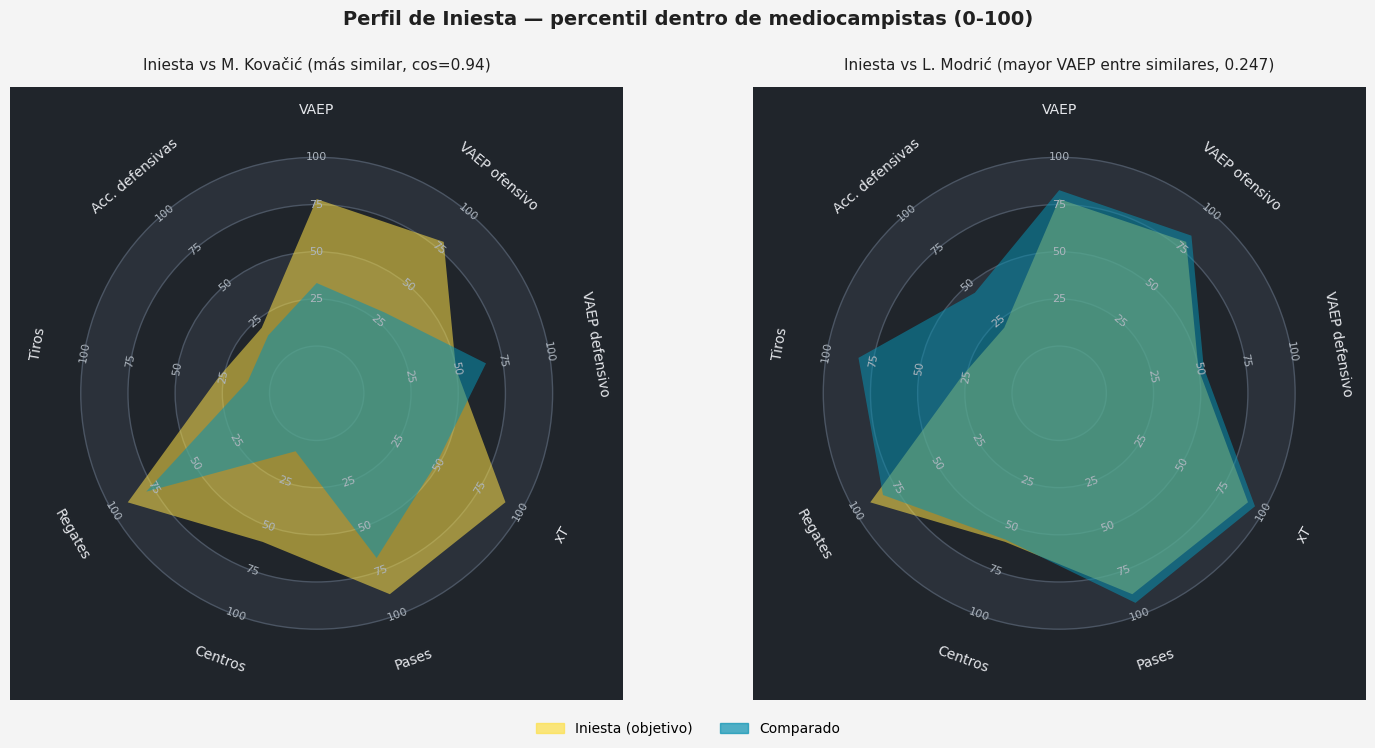

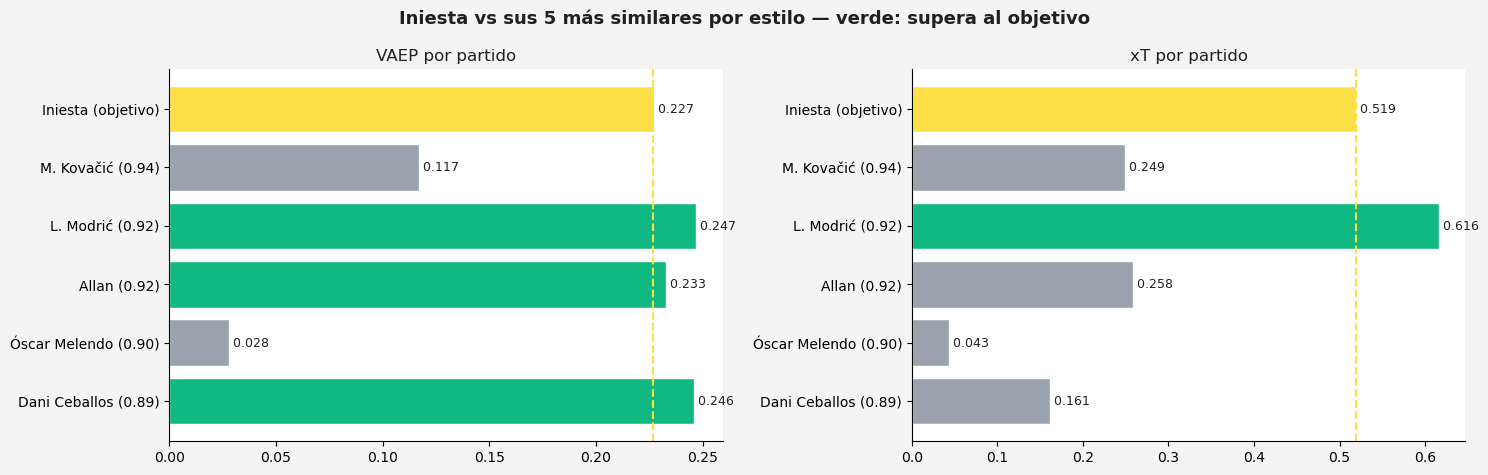

In [55]:
# ============================================================
# 5) Caso 1 — reemplazante de Iniesta (dejó el Barcelona al final de la 2017/18)
# ============================================================

def buscar_id(nombre):
    m = scout_base[scout_base['jugador'].str.contains(nombre, case=False, na=False)]
    return m[['jugador', 'posicion', 'edad', 'games', 'vaep_p90', 'xT_p90']]

print(buscar_id('Iniesta'))
ID_INIESTA = int(buscar_id('Iniesta').index[0])

reporte_iniesta = scouting_report(ID_INIESTA, top_n=5, misma_posicion=True)

=== SCOUTING: L. Messi (Delantero, 31 años, 36 partidos, cluster 3) ===
VAEP p90 0.972 | xT p90 0.738 | percentil VAEP entre delanteros: 100
           rank       jugador posicion  edad  games  cluster  similarity  vaep_p90  off_p90  def_p90  xT_p90  delta_vaep  mejora_vaep  mas_joven
player_id                                                                                                                                       
3359          0      L. Messi       FW  31.0     36        3       1.000     0.972    1.004   -0.032   0.738       0.000        False      False
134484        1  A. Ciciretti       FW  24.5     12        3       0.887     0.176    0.170    0.006   0.253      -0.796        False       True
3361          2    A. Sánchez       FW  29.5     31        3       0.872     0.308    0.332   -0.024   0.628      -0.663        False       True
7972          3     L. Suárez       FW  31.4     33        3       0.858     0.485    0.507   -0.022   0.231      -0.487        False 

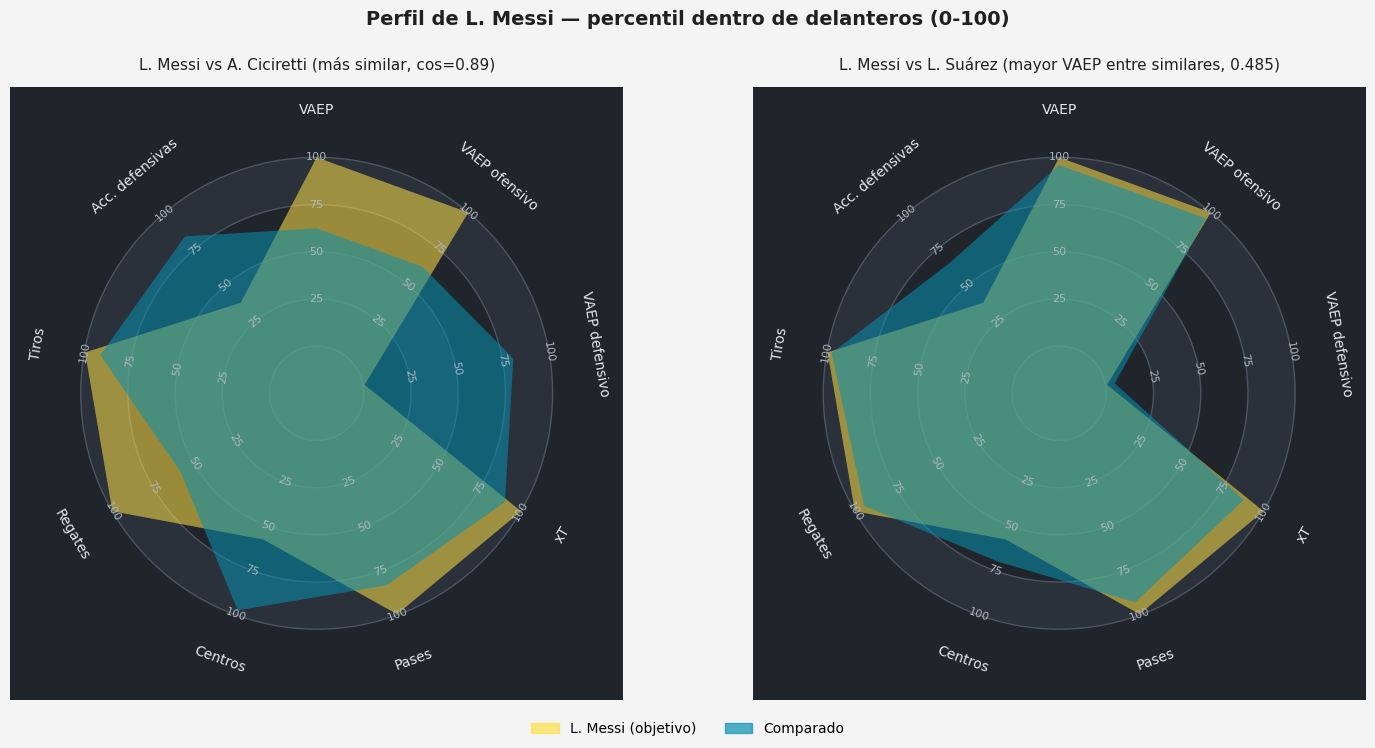

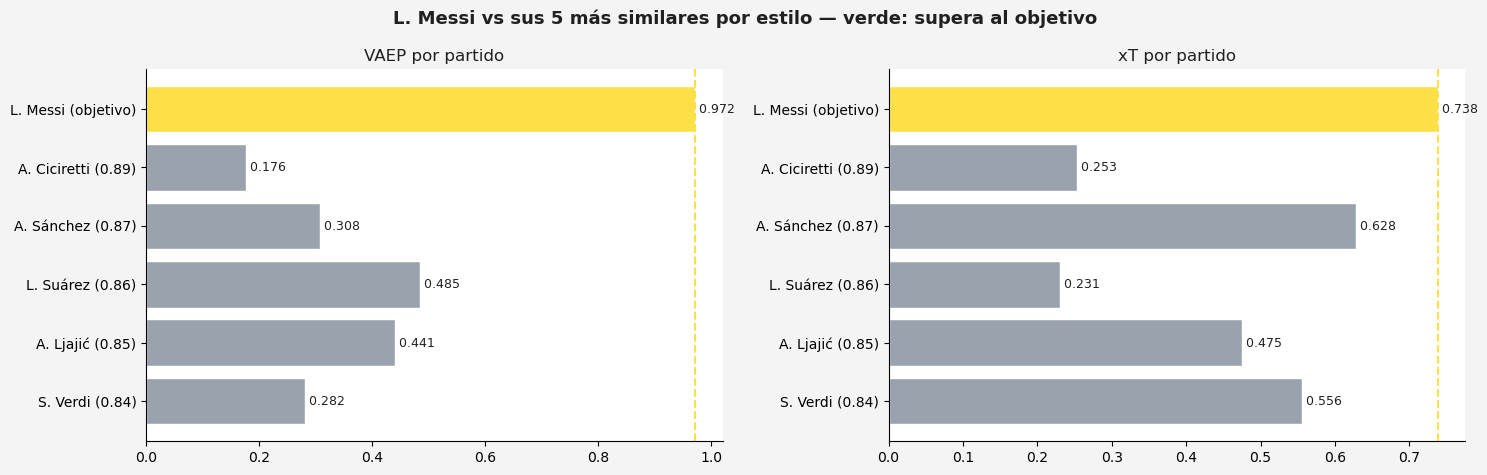


--- Sin filtro de posición ---
 rank        jugador posicion  similarity  vaep_p90   xT_p90
    1      E. Bardhi       MD    0.904083  0.412306 0.297152
    2 Renato Sanches       MD    0.895927  0.065820 0.277247
    3   A. Ciciretti       FW    0.886819  0.175732 0.252974
    4     João Pedro       MD    0.883635  0.190486 0.207837
    5     A. Sánchez       FW    0.871791  0.308455 0.628026


In [56]:
# ============================================================
# 6) Caso 2 — Messi (en el Ej. 4 fue el más alejado de cualquier arquetipo)
# ============================================================

ID_MESSI = 3359
reporte_messi = scouting_report(ID_MESSI, top_n=5, misma_posicion=True)

# ¿Cambia algo si no restringimos la posición?
print('\n--- Sin filtro de posición ---')
print(similares_por_estilo(ID_MESSI, top_n=5, misma_posicion=False)
      [['rank', 'jugador', 'posicion', 'similarity', 'vaep_p90', 'xT_p90']].to_string(index=False))

#### Conclusiones del Ejercicio 5

Para armar el sistema necesitábamos la posición de cada jugador, que no está en el dataset curado: la tomamos de `players.json` de Wyscout (GK, DF, MD, FW) junto con la fecha de nacimiento. El radar muestra 9 métricas por partido (VAEP total, ofensivo y defensivo, xT, pases, centros, regates, tiros y acciones defensivas) expresadas como percentil dentro de la misma posición, así un 79 en VAEP se lee como "mejor que el 79% de los mediocampistas".

Para la similitud usamos coseno sobre las proporciones de tipo de acción estandarizadas, sin incluir las métricas de VAEP que sí tiene `X_cluster`. La idea es que "similar" responda si juega parecido, y recién después comparar cuánto vale cada uno. Se filtra por misma posición y un mínimo de 10 partidos.

**Caso Iniesta.** Se fue del Barcelona al terminar la temporada. 34 años, 30 partidos, VAEP 0.230 por partido (p79 entre mediocampistas) y xT 0.519, bastante alto porque su valor está en el pase.

| # | Jugador | Edad | Partidos | Similitud | VAEP | xT |
| :---: | :--- | :---: | :---: | :---: | :---: | :---: |
| 1 | M. Kovačić | 24 | 21 | 0.94 | 0.117 | 0.249 |
| 2 | L. Modrić | 33 | 26 | 0.92 | 0.250 | 0.616 |
| 3 | Allan | 28 | 38 | 0.92 | 0.236 | 0.258 |
| 4 | Óscar Melendo | 21 | 18 | 0.90 | 0.032 | 0.043 |
| 5 | Dani Ceballos | 22 | 11 | 0.89 | 0.253 | 0.161 |

El más parecido por estilo es Kovačić pero rinde la mitad en VAEP. Modrić, Allan y Ceballos lo superan: Modrić es el único que también lo supera en xT, aunque tiene 33 años; Allan es la opción más razonable de mercado (28 años y 38 partidos de muestra); Ceballos es más joven pero sus números salen de 11 partidos. Cuatro de los cinco son del cluster 1 (distribuidores), lo cual es consistente con el perfil de Iniesta.

**Caso Messi.** VAEP 0.973 (p100 entre delanteros) y xT 0.738. Sus 5 similares (Ciciretti, A. Sánchez, L. Suárez, Ljajić, Verdi) quedan entre 0.49 y 0.80 por debajo en VAEP; el más cercano es Suárez con 0.489. No hay candidato que lo supere, lo que va en línea con el Ejercicio 4, donde Messi era el jugador más alejado de cualquier arquetipo. Sin el filtro de posición sus dos más similares son mediocampistas (Bardhi y Renato Sanches), por eso el filtro es necesario. En el radar Messi y Suárez se ven casi iguales porque el percentil comprime los valores altos; la diferencia real se ve en el gráfico de barras.

Como en el resto del práctico, "p90" es en realidad por partido porque el dataset no tiene minutos jugados.